In [104]:
"""
analyze_pareto.py — Cancer Metastasis Pareto Front Analysis
============================================================
Reads the three CSVs produced by batch_sweep.py and generates seven
publication-quality figure groups in pareto_plots/.

Required input files (same directory as this script)
-----------------------------------------------------
    pareto_summary.csv  — one row per (α,β,γ,N_A) combination
    run_summary.csv     — one row per individual simulation run
    raw_runs.csv        — one row per (run, timestep)

Output
------
    pareto_plots/01_strategy_classification.png
    pareto_plots/02_parameter_mapping.png
    pareto_plots/03_tradeoff_matrix.png
    pareto_plots/04_phase_heatmaps_<objective>.png  (4 files)
    pareto_plots/05_time_evolution.png
    pareto_plots/06_sensitivity.png
    pareto_plots/07_advanced.png

Usage
-----
    python analyze_pareto.py
"""

from __future__ import annotations

import os
import warnings
import pathlib

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.cm import ScalarMappable
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import cdist
%matplotlib inline
from IPython.display import display

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
PARETO_CSV = "results/225 pairs-100 runs/pareto_summary.csv"
SUMM_CSV   = "results/225 pairs-100 runs/run_summary.csv"
RAW_CSV    = "results/225 pairs-100 runs/raw_runs.csv"
PLOT_DIR   = "results/225 pairs-100 runs/pareto_plots"

N_STRATEGIES = 4  # number of KMeans clusters

# Strategy display names, colours, and marker shapes.
# These are assigned post-hoc to clusters by centroid ranking — see _label_clusters().
STRATEGY_NAMES  = ["Efficient", "Invasive", "Necrotic", "Explosive"]
STRATEGY_COLORS = ["#2ecc71", "#e74c3c", "#9b59b6", "#f39c12"]
STRATEGY_MARKS  = ["o", "^", "s", "D"]

# Objective metadata: (column_prefix, display_name, direction)
# direction: +1 = maximise, -1 = minimise
OBJECTIVES = [
    ("fitness",     "Fitness",     +1),
    ("mei",         "MEI",         -1),
    ("ncf",         "NCF",         -1),
    ("dissipation", "Dissipation", -1),
]
OBJ_COLS   = [f"mean_{k}" for k, _, _ in OBJECTIVES]
OBJ_LABELS = [label for _, label, _ in OBJECTIVES]
OBJ_DIRS   = [d for _, _, d in OBJECTIVES]

PARAM_META = [
    ("alpha", "α  (death rate)"),
    ("beta",  "β  (growth rate)"),
    ("gamma", "γ  (phenotype)"),
    ("n_a",   "N_A  (angio. threshold)"),
]

# ─────────────────────────────────────────────────────────────────────────────
#  STYLE
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#161b22",
    "axes.edgecolor":    "#30363d",
    "axes.labelcolor":   "#c9d1d9",
    "axes.titlecolor":   "#e6edf3",
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "grid.color":        "#21262d",
    "grid.linewidth":    0.6,
    "text.color":        "#c9d1d9",
    "legend.facecolor":  "#161b22",
    "legend.edgecolor":  "#30363d",
    "legend.labelcolor": "#c9d1d9",
    "figure.dpi":        130,
    "font.family":       "DejaVu Sans",
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.labelsize":    9,
})

ACCENT = "#58a6ff"   # blue accent for single-series lines

In [105]:
def _save(fig, name: str):
    path = pathlib.Path(PLOT_DIR) / name
    fig.savefig(path, dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Saved {path}")

# ─────────────────────────────────────────────────────────────────────────────
#  DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
def load_data():
    print("Loading data …")
    pf  = pd.read_csv(PARETO_CSV)
    run = pd.read_csv(SUMM_CSV)
    # raw_runs can be large — only load if needed; we defer that to fig 05
    print(f"  pareto_summary : {len(pf):,} rows")
    print(f"  run_summary    : {len(run):,} rows")

    # Add missing columns for backward compatibility (2-param sweeps)
    for col, default in [("gamma", 0.0), ("n_a", 500)]:
        if col not in pf.columns:
            pf[col] = default
        if col not in run.columns:
            run[col] = default

    # Pareto-front subset
    front = pf[pf["pareto_front"] == True].copy().reset_index(drop=True)
    print(f"  Pareto front   : {len(front)} / {len(pf)} pairs")
    return pf, run, front

# ─────────────────────────────────────────────────────────────────────────────
#  STRATEGY CLUSTERING
# ─────────────────────────────────────────────────────────────────────────────
def _label_clusters(front: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """
    KMeans on normalised Pareto objectives.  Clusters are sorted so that the
    cluster with the highest mean fitness = 0 (Efficient) and the cluster with
    the highest mean MEI = 1 (Invasive), etc.
    Returns (labels array, centres in original scale).
    """
    X = front[OBJ_COLS].fillna(0).values
    scaler = MinMaxScaler()
    Xn = scaler.fit_transform(X)

    km = KMeans(n_clusters=N_STRATEGIES, n_init=20, random_state=42)
    raw_labels = km.fit_predict(Xn)
    centres_n  = km.cluster_centers_           # shape (4, 4)
    centres    = scaler.inverse_transform(centres_n)

    # Assign strategy names to cluster indices:
    #   Efficient  → highest fitness among clusters
    #   Invasive   → highest MEI
    #   Necrotic   → highest NCF
    #   Explosive  → highest dissipation
    obj_idx = {"fitness": 0, "mei": 1, "ncf": 2, "dissipation": 3}
    cluster_map = {}
    assigned    = set()
    for strategy_slot, (col, sign) in enumerate(
            [("fitness", -1), ("mei", 1), ("ncf", 1), ("dissipation", 1)]):
        # sign: -1 = we want the HIGHEST fitness (negate to get argmax of negated)
        #        1 = we want the HIGHEST mei/ncf/dissipation
        col_i = obj_idx[col]
        ranked = np.argsort(sign * centres[:, col_i])
        for cid in ranked:
            if cid not in assigned:
                cluster_map[cid] = strategy_slot
                assigned.add(cid)
                break

    labels = np.array([cluster_map[c] for c in raw_labels])
    return labels, centres

def assign_strategies(front: pd.DataFrame) -> pd.DataFrame:
    if len(front) < N_STRATEGIES:
        front = front.copy()
        front["strategy"] = 0
        front["strategy_name"]  = STRATEGY_NAMES[0]
        front["strategy_color"] = STRATEGY_COLORS[0]
        front["strategy_mark"]  = STRATEGY_MARKS[0]
        return front
    labels, _ = _label_clusters(front)
    front = front.copy()
    front["strategy"]       = labels
    front["strategy_name"]  = [STRATEGY_NAMES[l]  for l in labels]
    front["strategy_color"] = [STRATEGY_COLORS[l] for l in labels]
    front["strategy_mark"]  = [STRATEGY_MARKS[l]  for l in labels]
    return front

def _scatter_by_strategy(ax, front, xcol, ycol, size=55, alpha=0.85):
    for s_idx, name in enumerate(STRATEGY_NAMES):
        sub = front[front["strategy"] == s_idx]
        if sub.empty:
            continue
        ax.scatter(sub[xcol], sub[ycol],
                   c=STRATEGY_COLORS[s_idx], marker=STRATEGY_MARKS[s_idx],
                   s=size, alpha=alpha, label=name, edgecolors="none", zorder=3)

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 01 — STRATEGY CLASSIFICATION
# ─────────────────────────────────────────────────────────────────────────────

In [106]:
def fig01_strategy_classification(front: pd.DataFrame):
    fig = plt.figure(figsize=(16, 5))
    fig.suptitle("Pareto Front — Strategy Classification", fontsize=13,
                 color="#e6edf3", y=1.01)

    pairs = [("mean_fitness","mean_mei"), ("mean_fitness","mean_ncf"), ("mean_mei","mean_ncf")]
    xlabels = ["Fitness", "Fitness", "MEI"]
    ylabels = ["MEI",     "NCF",     "NCF"]

    axes = fig.subplots(1, 3)
    for ax, (xc, yc), xl, yl in zip(axes, pairs, xlabels, ylabels):
        _scatter_by_strategy(ax, front, xc, yc)
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_title(f"{xl} vs {yl}")
        ax.grid(True, alpha=0.3)

    # Single legend for all panels
    handles = [mpatches.Patch(color=STRATEGY_COLORS[i], label=STRATEGY_NAMES[i])
               for i in range(N_STRATEGIES)]
    fig.legend(handles=handles, loc="lower center", ncol=N_STRATEGIES,
               bbox_to_anchor=(0.5, -0.07), framealpha=0.4, fontsize=9)

    # Strategy description table
    rows = [
        ("Efficient",  "High fitness, low MEI, low NCF, low dissipation"),
        ("Invasive",   "High MEI, moderate fitness — aggressive metastasis"),
        ("Necrotic",   "High NCF — large necrotic core, low viability"),
        ("Explosive",  "High dissipation — fast growth, high energetic cost"),
    ]
    col_labels = ["Strategy", "Characteristics"]
    table_data = [[r[0], r[1]] for r in rows]
    row_colors = [[STRATEGY_COLORS[i] + "44"]*2 for i in range(N_STRATEGIES)]

    # Add a text table below the figure
    y0 = -0.22
    for i, (name, desc) in enumerate(rows):
        fig.text(0.02, y0 - i*0.055, f"  {name}",
                 fontsize=8.5, color=STRATEGY_COLORS[i], fontweight="bold",
                 transform=fig.transFigure)
        fig.text(0.13, y0 - i*0.055, desc,
                 fontsize=8.5, color="#8b949e", transform=fig.transFigure)

    plt.tight_layout()
    display(fig)
    _save(fig, "01_strategy_classification.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 02 — PARAMETER MAPPING ON PARETO FRONT
# ─────────────────────────────────────────────────────────────────────────────

In [107]:
def fig02_parameter_mapping(front: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle("Parameter Mapping on Pareto Front\n(Fitness vs MEI, coloured by each parameter)",
                 fontsize=12, color="#e6edf3")

    cmaps = ["plasma", "viridis", "coolwarm", "cividis"]

    for ax, (pcol, plabel), cmap in zip(axes.flat, PARAM_META, cmaps):
        if pcol not in front.columns or front[pcol].nunique() < 2:
            ax.set_visible(False)
            continue
        sc = ax.scatter(front["mean_fitness"], front["mean_mei"],
                        c=front[pcol], cmap=cmap, s=80, alpha=0.9,
                        edgecolors="#ffffff22", linewidths=0.4, zorder=3)
        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(plabel, fontsize=8)
        ax.set_xlabel("Fitness")
        ax.set_ylabel("MEI")
        ax.set_title(f"Coloured by  {plabel}")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    display(fig)
    _save(fig, "02_parameter_mapping.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 03 — PAIRWISE TRADE-OFF MATRIX
# ─────────────────────────────────────────────────────────────────────────────

In [108]:
def fig03_tradeoff_matrix(front: pd.DataFrame):
    n = len(OBJ_COLS)
    fig, axes = plt.subplots(n, n, figsize=(13, 12))
    fig.suptitle("Pairwise Objective Trade-offs — Pareto Front",
                 fontsize=12, color="#e6edf3", y=1.01)

    for row in range(n):
        for col in range(n):
            ax = axes[row][col]
            if row == col:
                # Diagonal: histogram per strategy
                for s_idx, name in enumerate(STRATEGY_NAMES):
                    sub = front[front["strategy"] == s_idx]
                    if not sub.empty:
                        ax.hist(sub[OBJ_COLS[row]], bins=8, alpha=0.55,
                                color=STRATEGY_COLORS[s_idx], density=True)
                ax.set_xlabel(OBJ_LABELS[row], fontsize=8)
                ax.set_yticks([])
            elif row > col:
                # Lower triangle: scatter coloured by strategy
                _scatter_by_strategy(ax, front, OBJ_COLS[col], OBJ_COLS[row], size=40)
                ax.set_xlabel(OBJ_LABELS[col], fontsize=8)
                ax.set_ylabel(OBJ_LABELS[row], fontsize=8)
                ax.grid(True, alpha=0.2)
            else:
                # Upper triangle: Pearson r annotation
                xv = front[OBJ_COLS[col]].values
                yv = front[OBJ_COLS[row]].values
                mask = np.isfinite(xv) & np.isfinite(yv)
                if mask.sum() > 2:
                    r = np.corrcoef(xv[mask], yv[mask])[0, 1]
                    color = "#e74c3c" if r < -0.3 else "#2ecc71" if r > 0.3 else "#8b949e"
                    ax.text(0.5, 0.5, f"r = {r:+.2f}", ha="center", va="center",
                            fontsize=14, color=color, fontweight="bold",
                            transform=ax.transAxes)
                ax.set_xlabel(OBJ_LABELS[col], fontsize=8)
                ax.set_ylabel(OBJ_LABELS[row], fontsize=8)
                ax.set_facecolor("#0d1117")

            ax.tick_params(labelsize=7)

    # Legend outside
    handles = [mpatches.Patch(color=STRATEGY_COLORS[i], label=STRATEGY_NAMES[i])
               for i in range(N_STRATEGIES)]
    fig.legend(handles=handles, loc="lower center", ncol=N_STRATEGIES,
               bbox_to_anchor=(0.5, -0.03), framealpha=0.4, fontsize=9)
    plt.tight_layout()
    display(fig)
    _save(fig, "03_tradeoff_matrix.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 04 — PHASE HEATMAPS (α vs β for each γ, N_A combo)
# ─────────────────────────────────────────────────────────────────────────────

In [109]:
def fig04_phase_heatmaps(pf: pd.DataFrame):
    """One figure per objective: 3×3 grid of α vs β heatmaps."""
    gamma_vals = sorted(pf["gamma"].unique())
    na_vals    = sorted(pf["n_a"].unique())
    nrow, ncol = len(gamma_vals), len(na_vals)

    cmaps_obj = ["YlOrRd", "Blues", "Purples", "hot"]

    for (obj_col, obj_label, _), cmap in zip(OBJECTIVES, cmaps_obj):
        mean_col = f"mean_{obj_col}"
        if mean_col not in pf.columns:
            continue

        fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 4*nrow))
        fig.suptitle(f"Phase Diagram — {obj_label}\n(α vs β for each γ × N_A combination)",
                     fontsize=12, color="#e6edf3", y=1.01)

        # Determine global colour scale
        vmin = pf[mean_col].min()
        vmax = pf[mean_col].max()

        for ri, gamma in enumerate(gamma_vals):
            for ci, na in enumerate(na_vals):
                ax = axes[ri][ci] if nrow > 1 else axes[ci]
                sub = pf[(pf["gamma"] == gamma) & (pf["n_a"] == na)]

                if sub.empty:
                    ax.set_visible(False)
                    continue

                pivot = sub.pivot_table(index="alpha", columns="beta",
                                        values=mean_col, aggfunc="mean")
                im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                               vmin=vmin, vmax=vmax, origin="lower",
                               interpolation="nearest")
                ax.set_xticks(range(len(pivot.columns)))
                ax.set_yticks(range(len(pivot.index)))
                ax.set_xticklabels([f"{v:.2f}" for v in pivot.columns], fontsize=7)
                ax.set_yticklabels([f"{v:.2f}" for v in pivot.index],   fontsize=7)
                ax.set_xlabel("β", fontsize=8)
                ax.set_ylabel("α", fontsize=8)
                ax.set_title(f"γ={gamma}, N_A={int(na)}", fontsize=9)

                # Annotate each cell with its value
                for (r, c), val in np.ndenumerate(pivot.values):
                    if np.isfinite(val):
                        ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                                fontsize=6.5, color="white",
                                bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.3))

        # Shared colorbar
        fig.subplots_adjust(right=0.88)
        cax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
        sm  = ScalarMappable(cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        fig.colorbar(sm, cax=cax, label=obj_label)

        display(fig)
        _save(fig, f"04_phase_heatmaps_{obj_col}.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 05 — TIME EVOLUTION OF REPRESENTATIVE RUNS
# ─────────────────────────────────────────────────────────────────────────────

In [110]:
def fig05_time_evolution(front: pd.DataFrame, run: pd.DataFrame):
    print("  Loading raw_runs.csv for time evolution …")
    try:
        raw = pd.read_csv(RAW_CSV)
    except FileNotFoundError:
        print("  raw_runs.csv not found — skipping figure 05")
        return

    # Add missing columns for backward compatibility
    for col, default in [("gamma", 0.0), ("n_a", 500)]:
        if col not in raw.columns:
            raw[col] = default
        if col not in run.columns:
            run[col] = default

    keys = ["alpha", "beta", "gamma", "n_a"]

    # For each strategy, find the run closest to its centroid in objective space
    rep_runs = {}
    for s_idx, name in enumerate(STRATEGY_NAMES):
        sub_front = front[front["strategy"] == s_idx]
        if sub_front.empty:
            continue
        # Pick the Pareto point with median fitness in this cluster
        median_fitness = sub_front["mean_fitness"].median()
        best_row = sub_front.iloc[(sub_front["mean_fitness"] - median_fitness).abs().argsort()[:1]]

        # Find a real run from run_summary matching these parameters
        q = best_row.iloc[0]
        match = run.copy()
        for k in keys:
            if k in match.columns:
                match = match[match[k] == q[k]]
        ok_runs = match[match["status"] == "ok"]
        if ok_runs.empty:
            continue

        # Pick the run with median fitness
        med = ok_runs["fitness"].median()
        chosen = ok_runs.iloc[(ok_runs["fitness"] - med).abs().argsort()[:1]].iloc[0]

        # Fetch its history from raw_runs
        hist = raw.copy()
        for k in keys:
            if k in hist.columns:
                hist = hist[hist[k] == chosen[k]]
        hist = hist[hist["run_id"] == chosen["run_id"]].sort_values("sim_time")

        if not hist.empty:
            rep_runs[s_idx] = (name, chosen, hist)

    if not rep_runs:
        print("  No representative runs found — skipping figure 05")
        return

    quantities = [
        ("population",       "Cell Population"),
        ("avg_b",            "Mean division prob. ⟨b⟩"),
        ("avg_d",            "Mean death prob. ⟨d⟩"),
        ("metastatic_cells", "Metastatic events / step"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("Time Evolution — Representative Run per Strategy",
                 fontsize=12, color="#e6edf3")

    for ax, (col, label) in zip(axes.flat, quantities):
        for s_idx, (name, info, hist) in rep_runs.items():
            t = hist["sim_time"].values
            y = hist[col].values
            ax.plot(t, y, color=STRATEGY_COLORS[s_idx], lw=2,
                    marker=STRATEGY_MARKS[s_idx], markersize=4,
                    markevery=max(1, len(t)//10), label=name, alpha=0.9)
        ax.set_xlabel("Simulation time")
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, framealpha=0.5)

    # Annotate parameter values for each strategy
    y_ann = -0.08
    for s_idx, (name, info, _) in rep_runs.items():
        param_str = (f"α={info['alpha']}, β={info['beta']}, "
                     f"γ={info.get('gamma', 0.0)}, N_A={int(info.get('n_a', 500))}")
        fig.text(0.01 + s_idx*0.25, y_ann, f"[{name}]  {param_str}",
                 fontsize=7.5, color=STRATEGY_COLORS[s_idx],
                 transform=fig.transFigure)

    plt.tight_layout()
    display(fig)
    _save(fig, "05_time_evolution.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 06 — SENSITIVITY ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

In [111]:
def fig06_sensitivity(pf: pd.DataFrame):
    """
    For each (parameter, objective) pair, plot the mean objective value as the
    parameter varies (with all other parameters pooled).  This is a marginal
    sensitivity — interpretable and model-free.
    """
    params = [(col, label) for col, label in PARAM_META if col in pf.columns]
    n_obj  = len(OBJECTIVES)
    n_par  = len(params)

    fig, axes = plt.subplots(n_obj, n_par, figsize=(4*n_par, 3.5*n_obj))
    fig.suptitle("Sensitivity Analysis — Marginal Mean of Each Objective vs Each Parameter\n"
                 "(all other parameters pooled)",
                 fontsize=11, color="#e6edf3", y=1.01)

    for ri, (obj_col, obj_label, _) in enumerate(OBJECTIVES):
        mean_col = f"mean_{obj_col}"
        std_col  = f"std_{obj_col}"
        if mean_col not in pf.columns:
            continue

        for ci, (pcol, plabel) in enumerate(params):
            ax = axes[ri][ci] if n_obj > 1 else axes[ci]

            grouped = pf.groupby(pcol)[mean_col]
            gm = grouped.mean()
            gs = grouped.std().fillna(0)
            xvals = gm.index.values.astype(float)

            ax.plot(xvals, gm.values, color=ACCENT, lw=2, marker="o",
                    markersize=6, zorder=3)
            ax.fill_between(xvals, gm.values - gs.values, gm.values + gs.values,
                            color=ACCENT, alpha=0.18)
            ax.set_xlabel(plabel, fontsize=8)
            ax.set_ylabel(obj_label if ci == 0 else "", fontsize=8)
            if ri == 0:
                ax.set_title(plabel, fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=7)

            # Annotate with η² (fraction of variance explained by grouping)
            grand_mean = pf[mean_col].mean()
            ss_total   = ((pf[mean_col] - grand_mean) ** 2).sum()
            ss_between = sum(
                len(g) * (g.mean() - grand_mean)**2
                for _, g in pf.groupby(pcol)[mean_col]
            )
            eta2 = ss_between / ss_total if ss_total > 0 else 0.0
            ax.text(0.97, 0.05, f"η²={eta2:.2f}", ha="right", va="bottom",
                    transform=ax.transAxes, fontsize=7.5, color="#f39c12")

    plt.tight_layout()
    display(fig)
    _save(fig, "06_sensitivity.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 07 — ADVANCED: knee detection · correlation · dissipation vs fitness
# ─────────────────────────────────────────────────────────────────────────────

In [112]:
def fig07_advanced(front: pd.DataFrame):
    fig = plt.figure(figsize=(17, 5))
    fig.suptitle("Advanced Analysis — Knee Detection · Correlation · Dissipation",
                 fontsize=12, color="#e6edf3")
    axes = fig.subplots(1, 3)

    # ── Panel A: Knee detection on Fitness vs MEI ─────────────────────────────
    ax = axes[0]
    xv = front["mean_fitness"].values
    yv = front["mean_mei"].values
    mask = np.isfinite(xv) & np.isfinite(yv)
    xv, yv = xv[mask], yv[mask]

    # Utopia point: best of each (max fitness, min MEI)
    utopia = np.array([xv.max(), yv.min()])
    # Normalise to [0,1] for distance computation
    xn = (xv - xv.min()) / (np.ptp(xv) + 1e-12)
    yn = (yv - yv.min()) / (np.ptp(yv) + 1e-12)
    utopia_n = np.array([xn.max(), yn.min()])
    pts_n    = np.stack([xn, yn], axis=1)
    dists    = cdist(pts_n, utopia_n.reshape(1, -1)).ravel()
    knee_idx = np.argmin(dists)

    # Plot all Pareto points
    _scatter_by_strategy(ax, front[mask], "mean_fitness", "mean_mei", size=45)
    ax.scatter(xv[knee_idx], yv[knee_idx],
               c="#f1c40f", s=200, marker="*", zorder=5, label="Knee")
    ax.annotate(
        f" Knee\n α={front[mask].iloc[knee_idx]['alpha']}\n"
        f" β={front[mask].iloc[knee_idx]['beta']}",
        (xv[knee_idx], yv[knee_idx]),
        xytext=(8, 8), textcoords="offset points",
        fontsize=7.5, color="#f1c40f",
    )
    ax.set_xlabel("Fitness");  ax.set_ylabel("MEI")
    ax.set_title("Knee-point Detection\n(min distance to utopia)")
    ax.grid(True, alpha=0.3)
    handles = [mpatches.Patch(color=STRATEGY_COLORS[i], label=STRATEGY_NAMES[i])
               for i in range(N_STRATEGIES)]
    handles.append(mpatches.Patch(color="#f1c40f", label="Knee"))
    ax.legend(handles=handles, fontsize=7, framealpha=0.4)

    # ── Panel B: Correlation heatmap (all pairs in pareto_summary) ────────────
    ax = axes[1]
    corr_df = front[OBJ_COLS].rename(
        columns={c: l for c, l in zip(OBJ_COLS, OBJ_LABELS)}
    )
    corr = corr_df.corr(method="pearson")
    mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
    cmap_corr  = sns.diverging_palette(10, 133, as_cmap=True)
    sns.heatmap(
        corr, ax=ax, cmap=cmap_corr, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 9},
        linewidths=0.5, linecolor="#21262d",
        cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    )
    ax.set_title("Objective Correlation Matrix\n(Pareto front)")
    ax.tick_params(labelsize=8)

    # ── Panel C: Dissipation vs Fitness, sized by NCF ─────────────────────────
    ax = axes[2]
    valid = front.dropna(subset=["mean_dissipation", "mean_fitness", "mean_ncf"])
    ncf_norm = (valid["mean_ncf"] - valid["mean_ncf"].min()) / (np.ptp(valid["mean_ncf"]) + 1e-12)
    sizes = 30 + 200 * ncf_norm

    for s_idx, name in enumerate(STRATEGY_NAMES):
        sub = valid[valid["strategy"] == s_idx]
        if sub.empty:
            continue
        s_sizes = sizes.loc[sub.index]
        ax.scatter(sub["mean_fitness"], sub["mean_dissipation"],
                   c=STRATEGY_COLORS[s_idx], s=s_sizes, alpha=0.85,
                   marker=STRATEGY_MARKS[s_idx], edgecolors="#ffffff33",
                   linewidths=0.5, label=name, zorder=3)

    ax.set_xlabel("Fitness")
    ax.set_ylabel("Dissipation")
    ax.set_title("Dissipation vs Fitness\n(marker size ∝ NCF)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, framealpha=0.4)

    # Size legend
    for ncf_val, lbl in [(0.0, "NCF=0"), (0.5, "NCF=0.5"), (1.0, "NCF=1.0")]:
        s_ex = 30 + 200 * ncf_val
        ax.scatter([], [], s=s_ex, c="#8b949e", alpha=0.7, label=lbl)
    ax.legend(fontsize=7, framealpha=0.4, loc="upper right")

    plt.tight_layout()
    display(fig)
    _save(fig, "07_advanced.png")

# ─────────────────────────────────────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────────────────────────────────────

In [113]:
pathlib.Path(PLOT_DIR).mkdir(exist_ok=True)

print("=" * 60)
print("Cancer Metastasis — Pareto Front Analysis")
print("=" * 60)

pf, run, front = load_data()

if len(front) < 2:
    print("ERROR: Pareto front has fewer than 2 points — cannot cluster.")
    raise SystemExit(1)

print("\nClassifying strategies …")
front = assign_strategies(front)
counts = front.groupby("strategy_name").size()
for name, count in counts.items():
    print(f"  {name}: {count} pairs")

print("\nGenerating figures …")

Cancer Metastasis — Pareto Front Analysis
Loading data …
  pareto_summary : 225 rows
  run_summary    : 22,500 rows
  Pareto front   : 165 / 225 pairs

Classifying strategies …
  Efficient: 42 pairs
  Explosive: 11 pairs
  Invasive: 36 pairs
  Necrotic: 76 pairs

Generating figures …


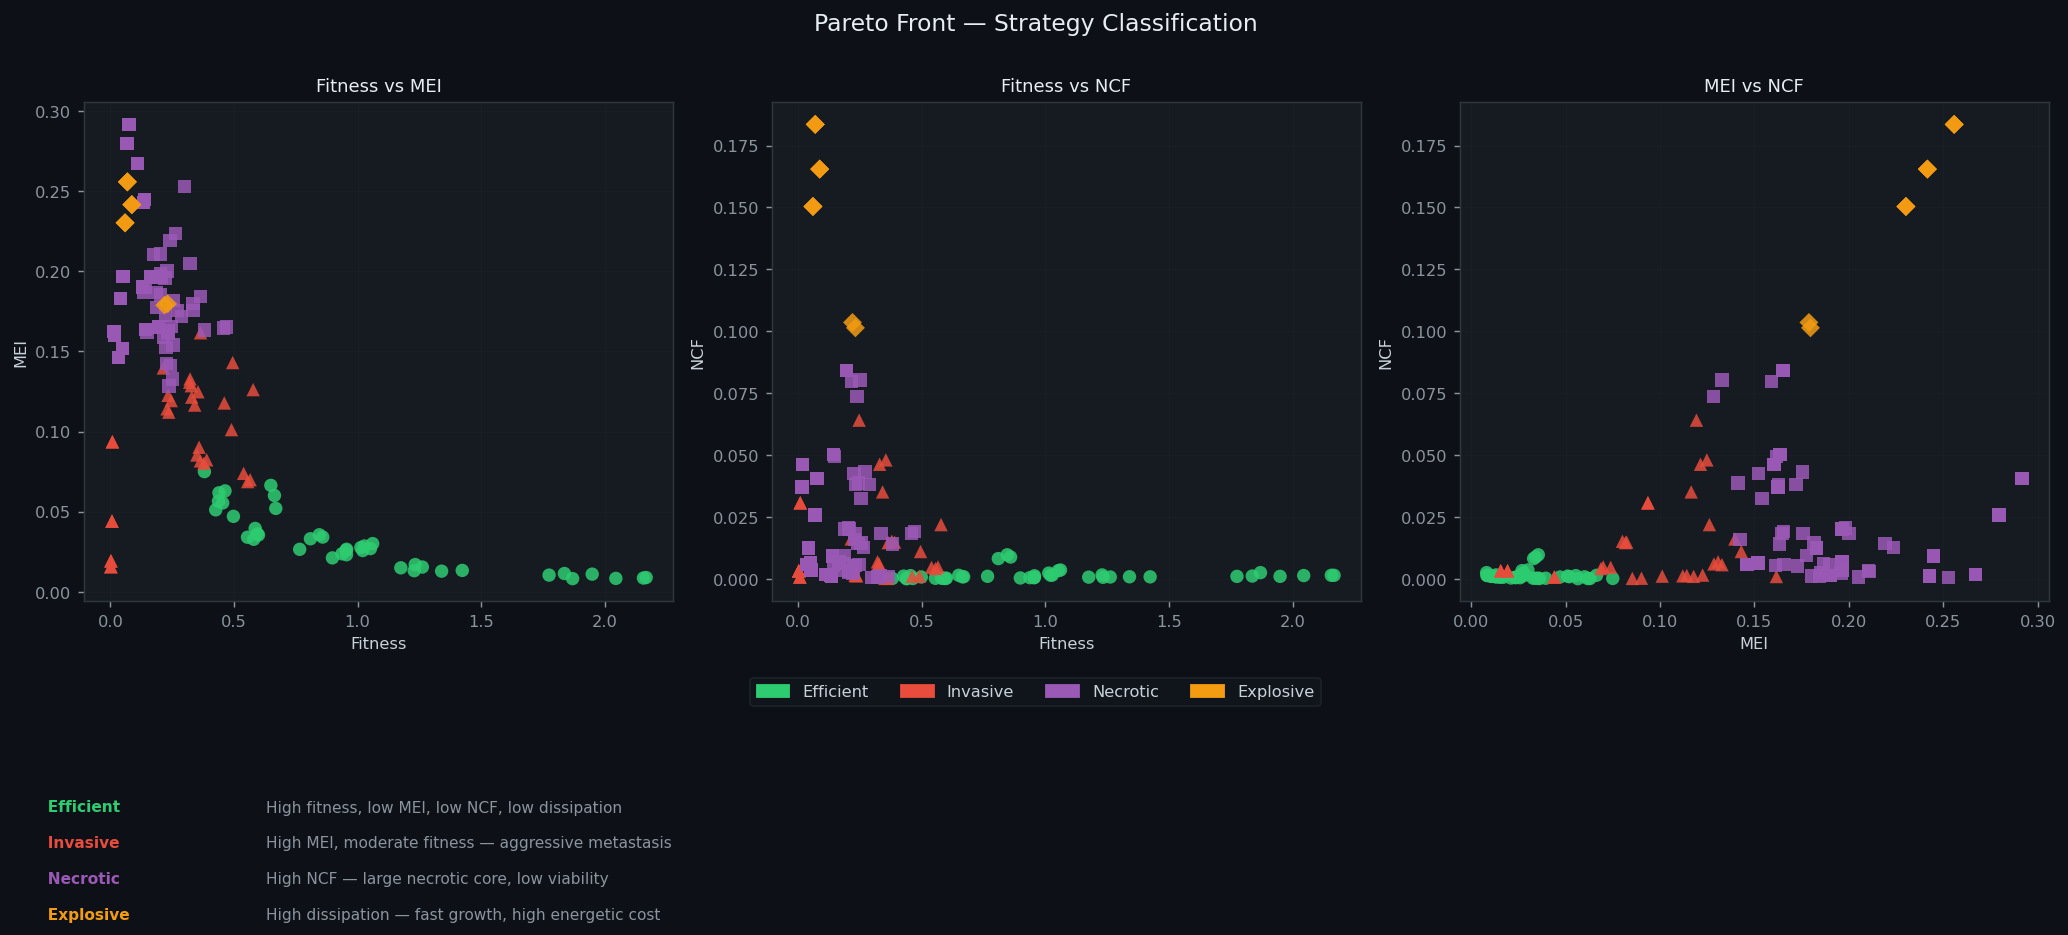

  Saved results\225 pairs-100 runs\pareto_plots\01_strategy_classification.png


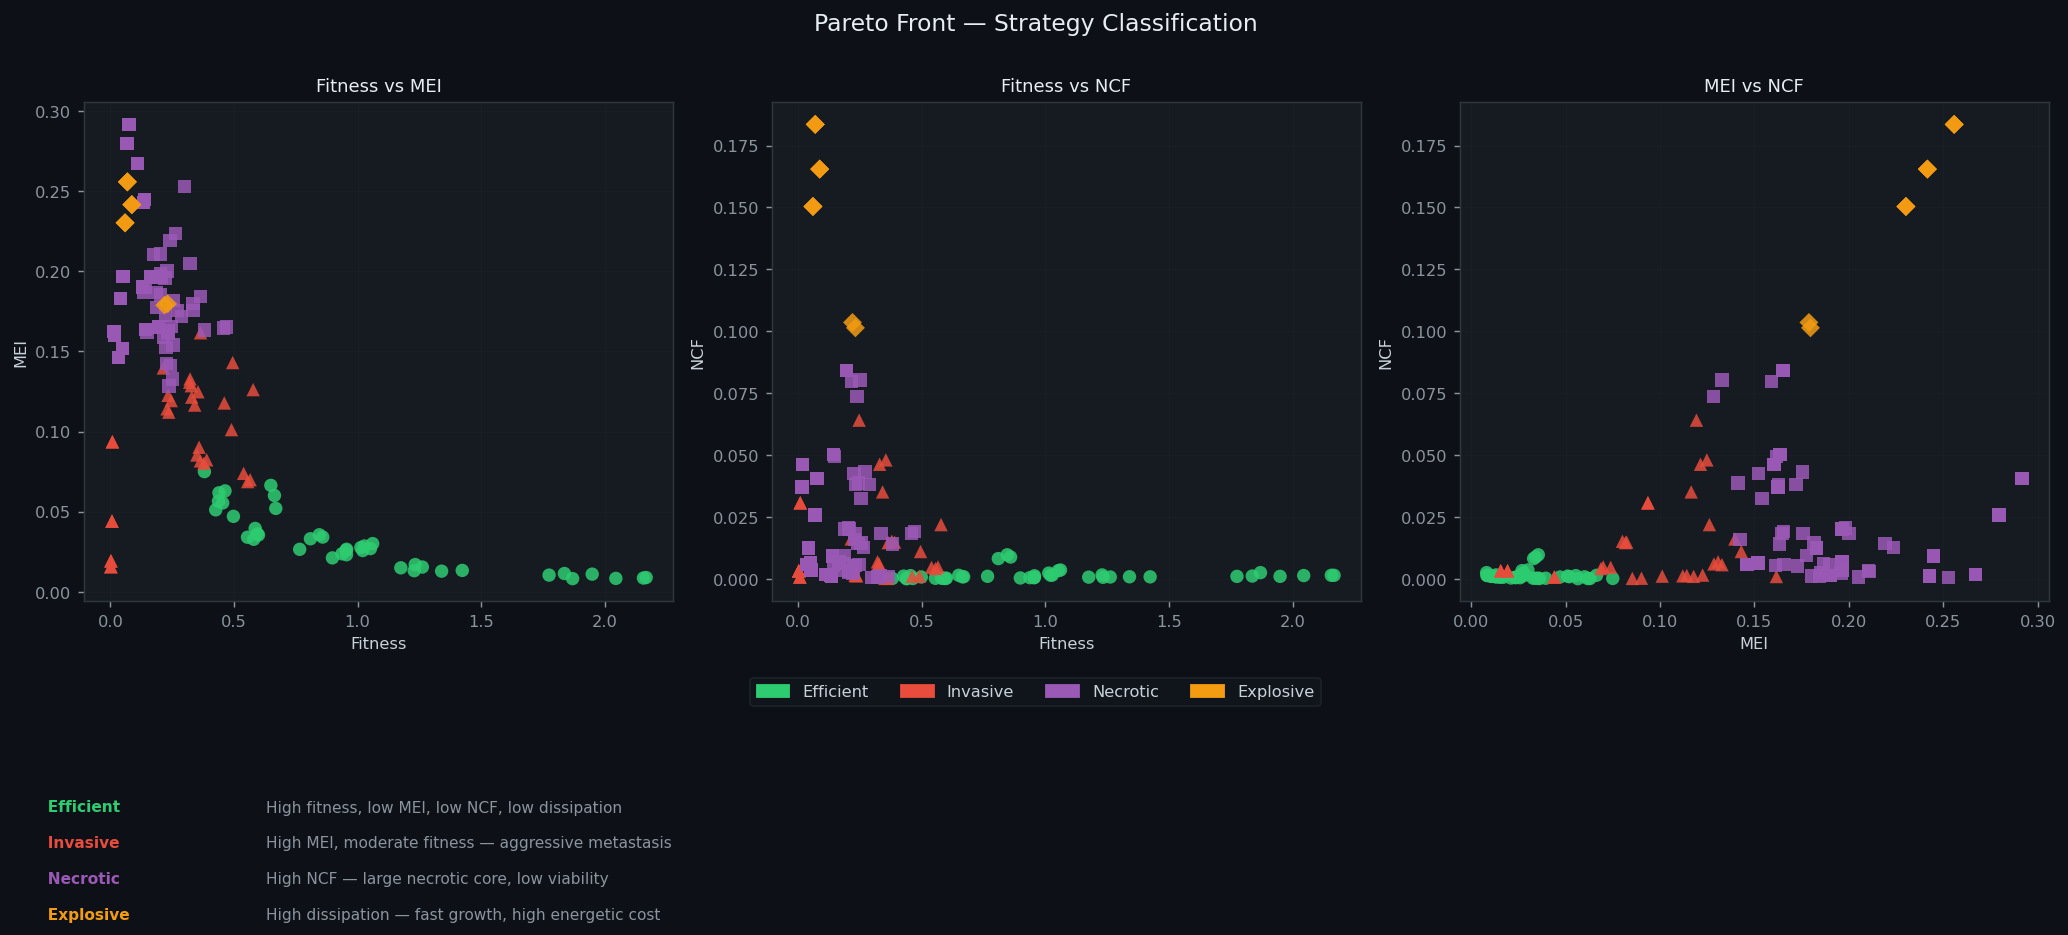

In [114]:
fig01_strategy_classification(front)

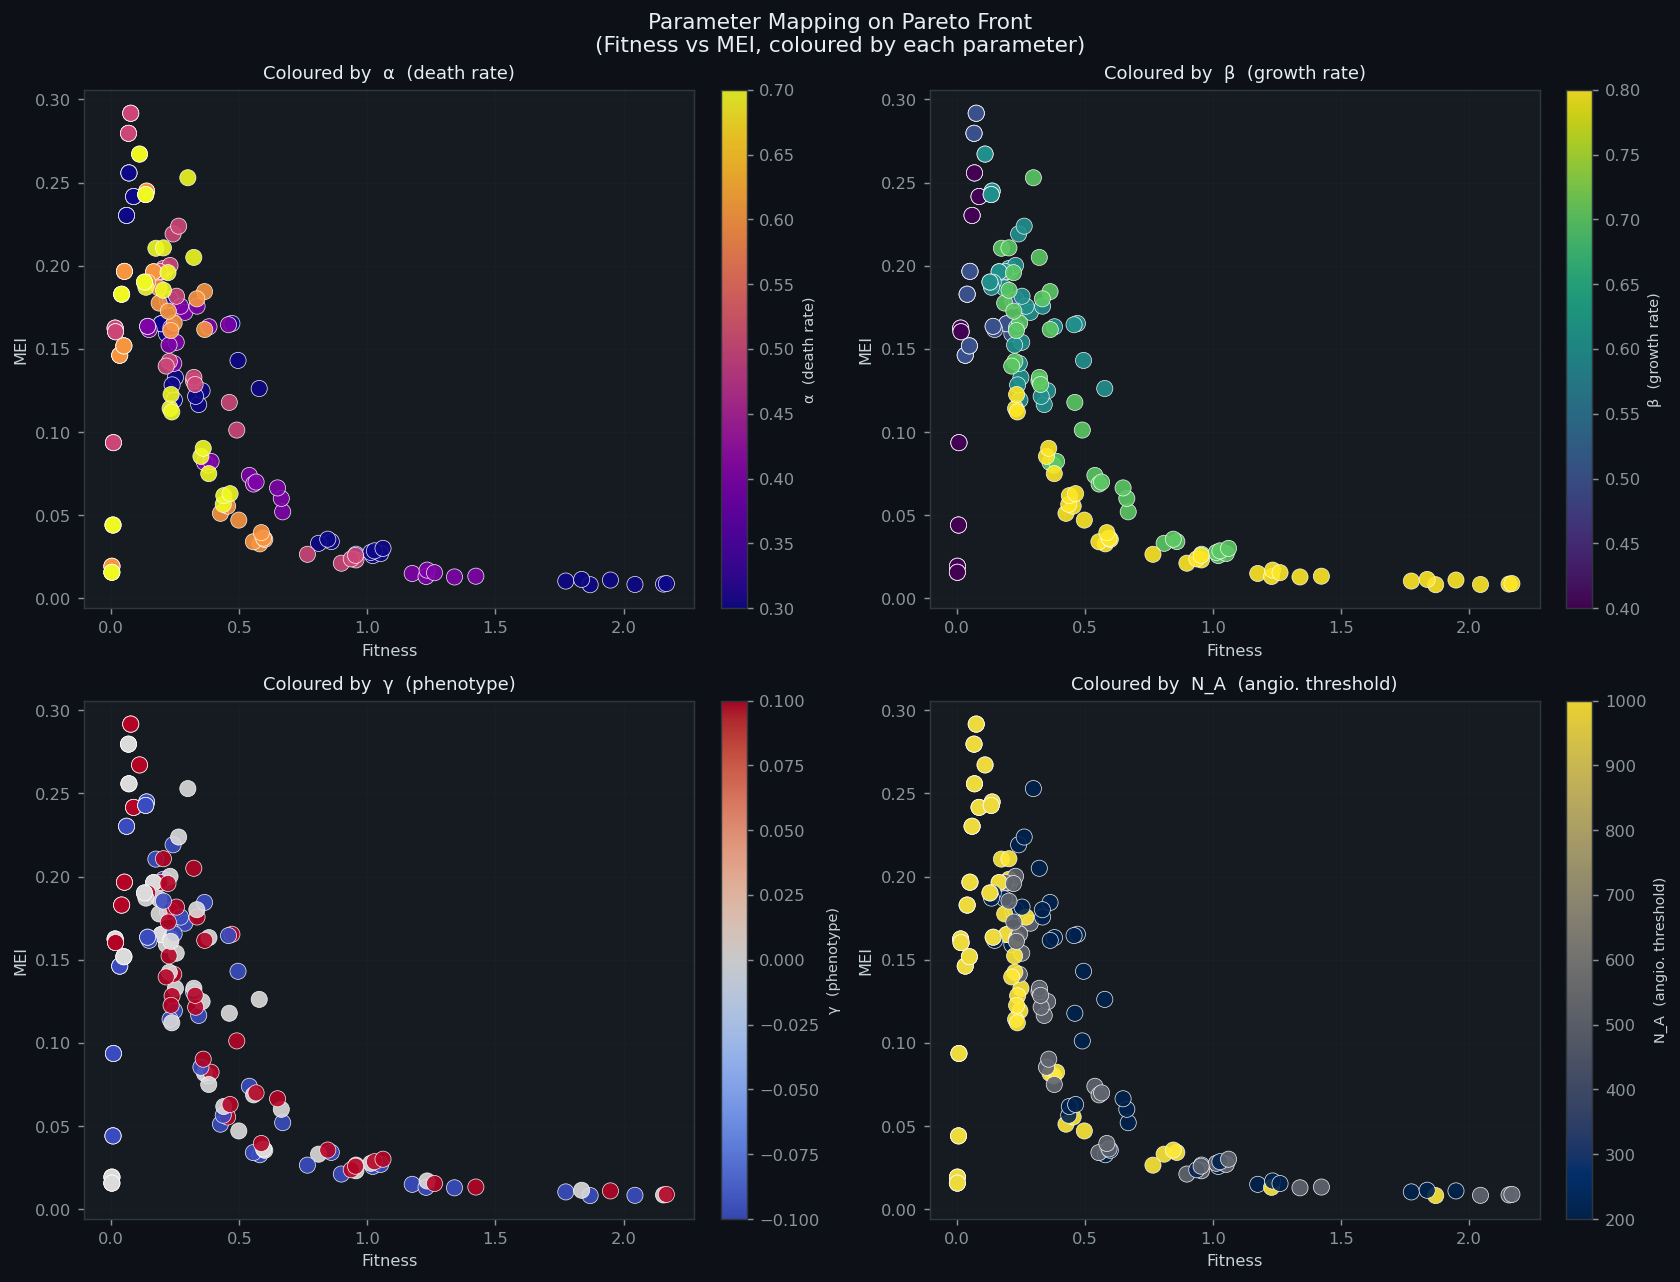

  Saved results\225 pairs-100 runs\pareto_plots\02_parameter_mapping.png


In [115]:
fig02_parameter_mapping(front)

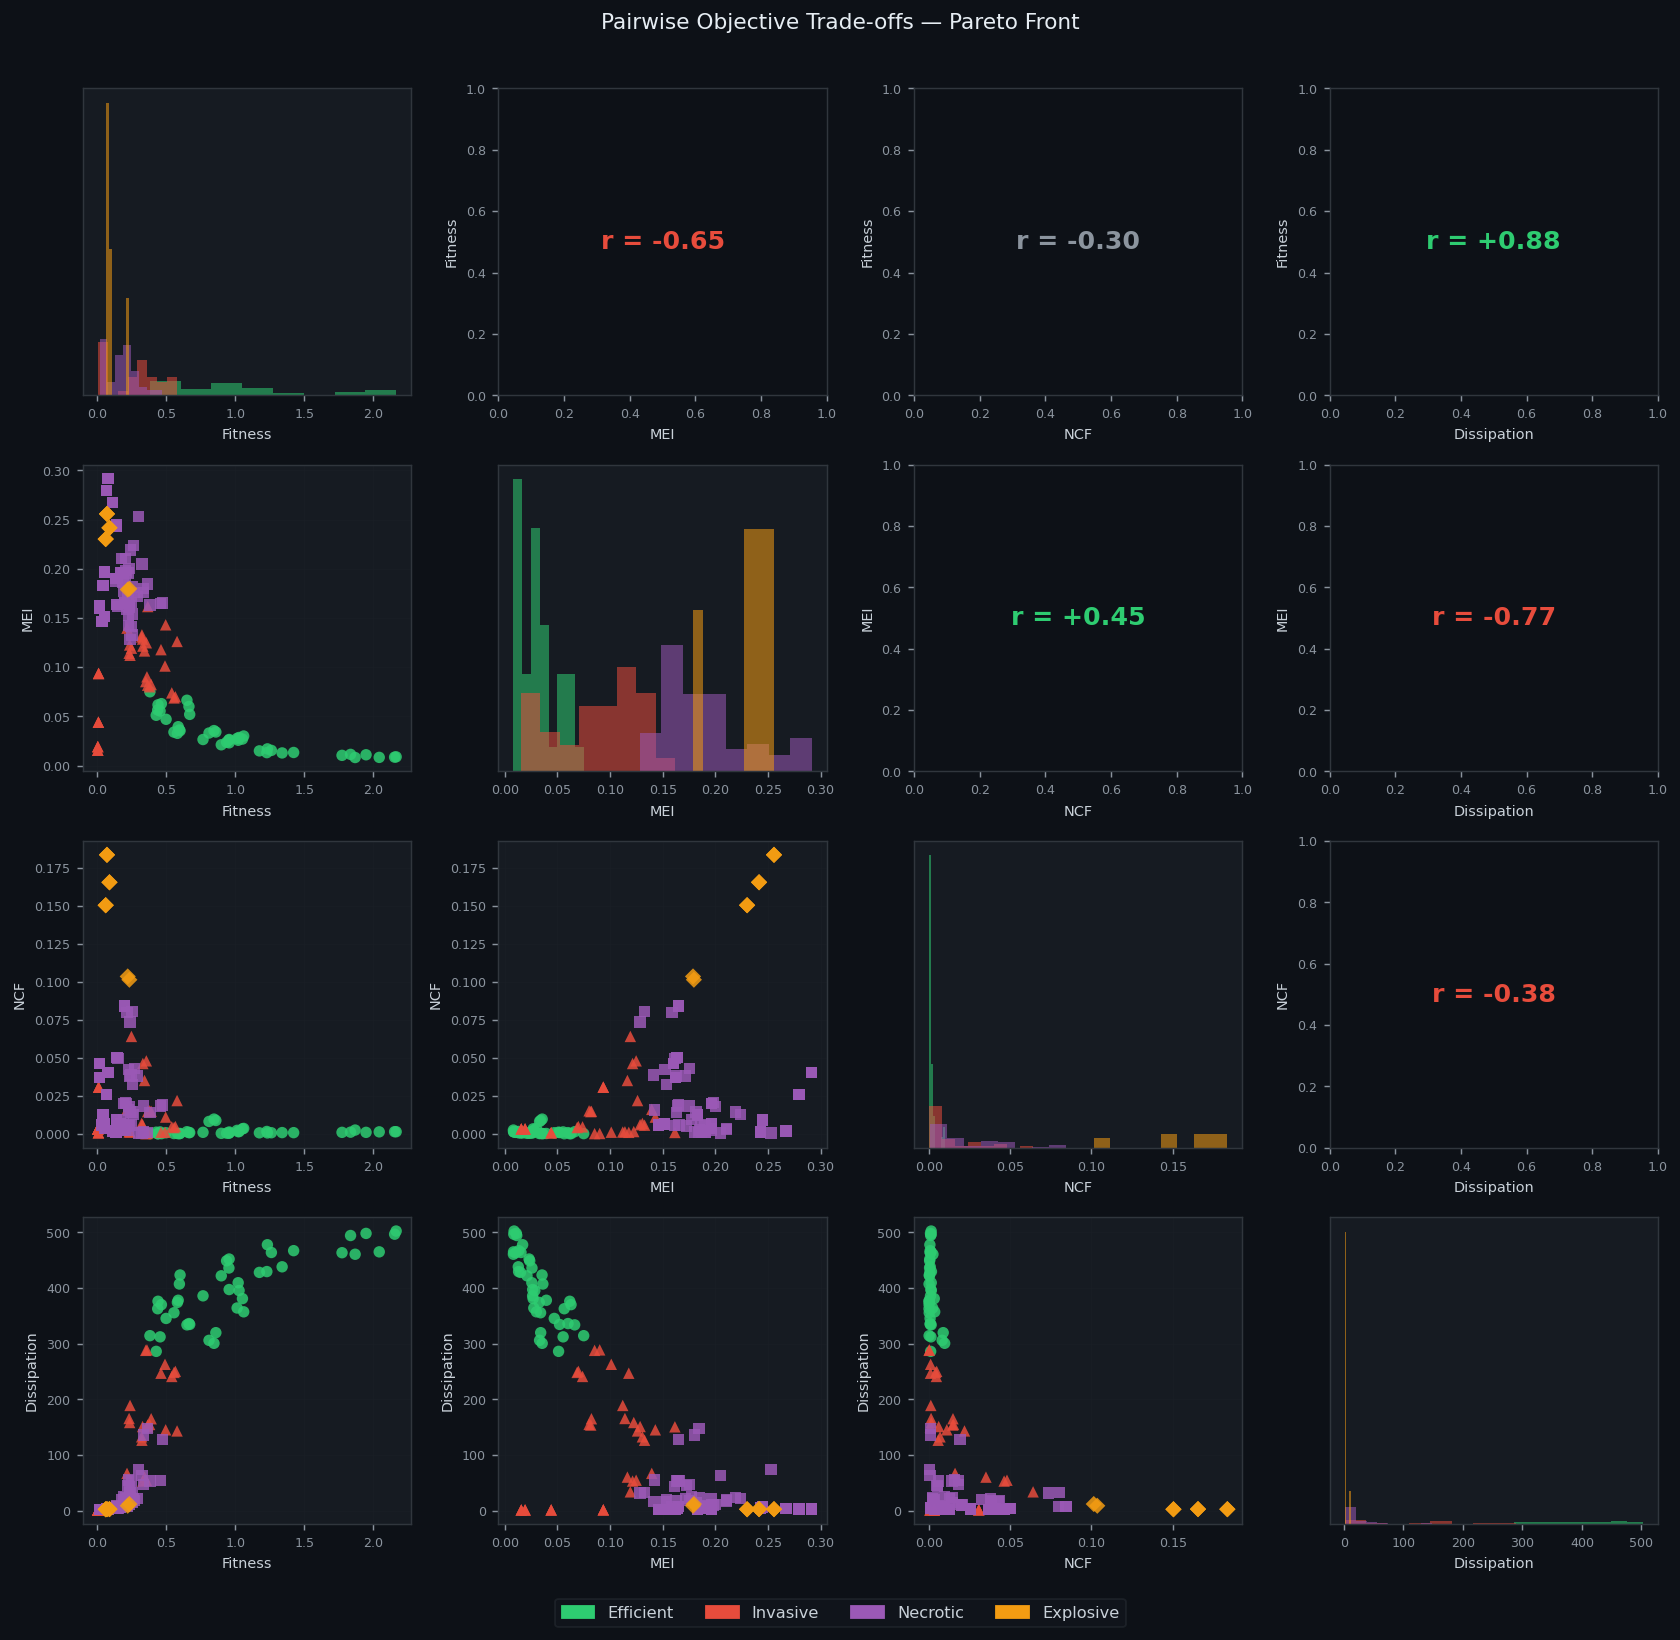

  Saved results\225 pairs-100 runs\pareto_plots\03_tradeoff_matrix.png


In [116]:
fig03_tradeoff_matrix(front)

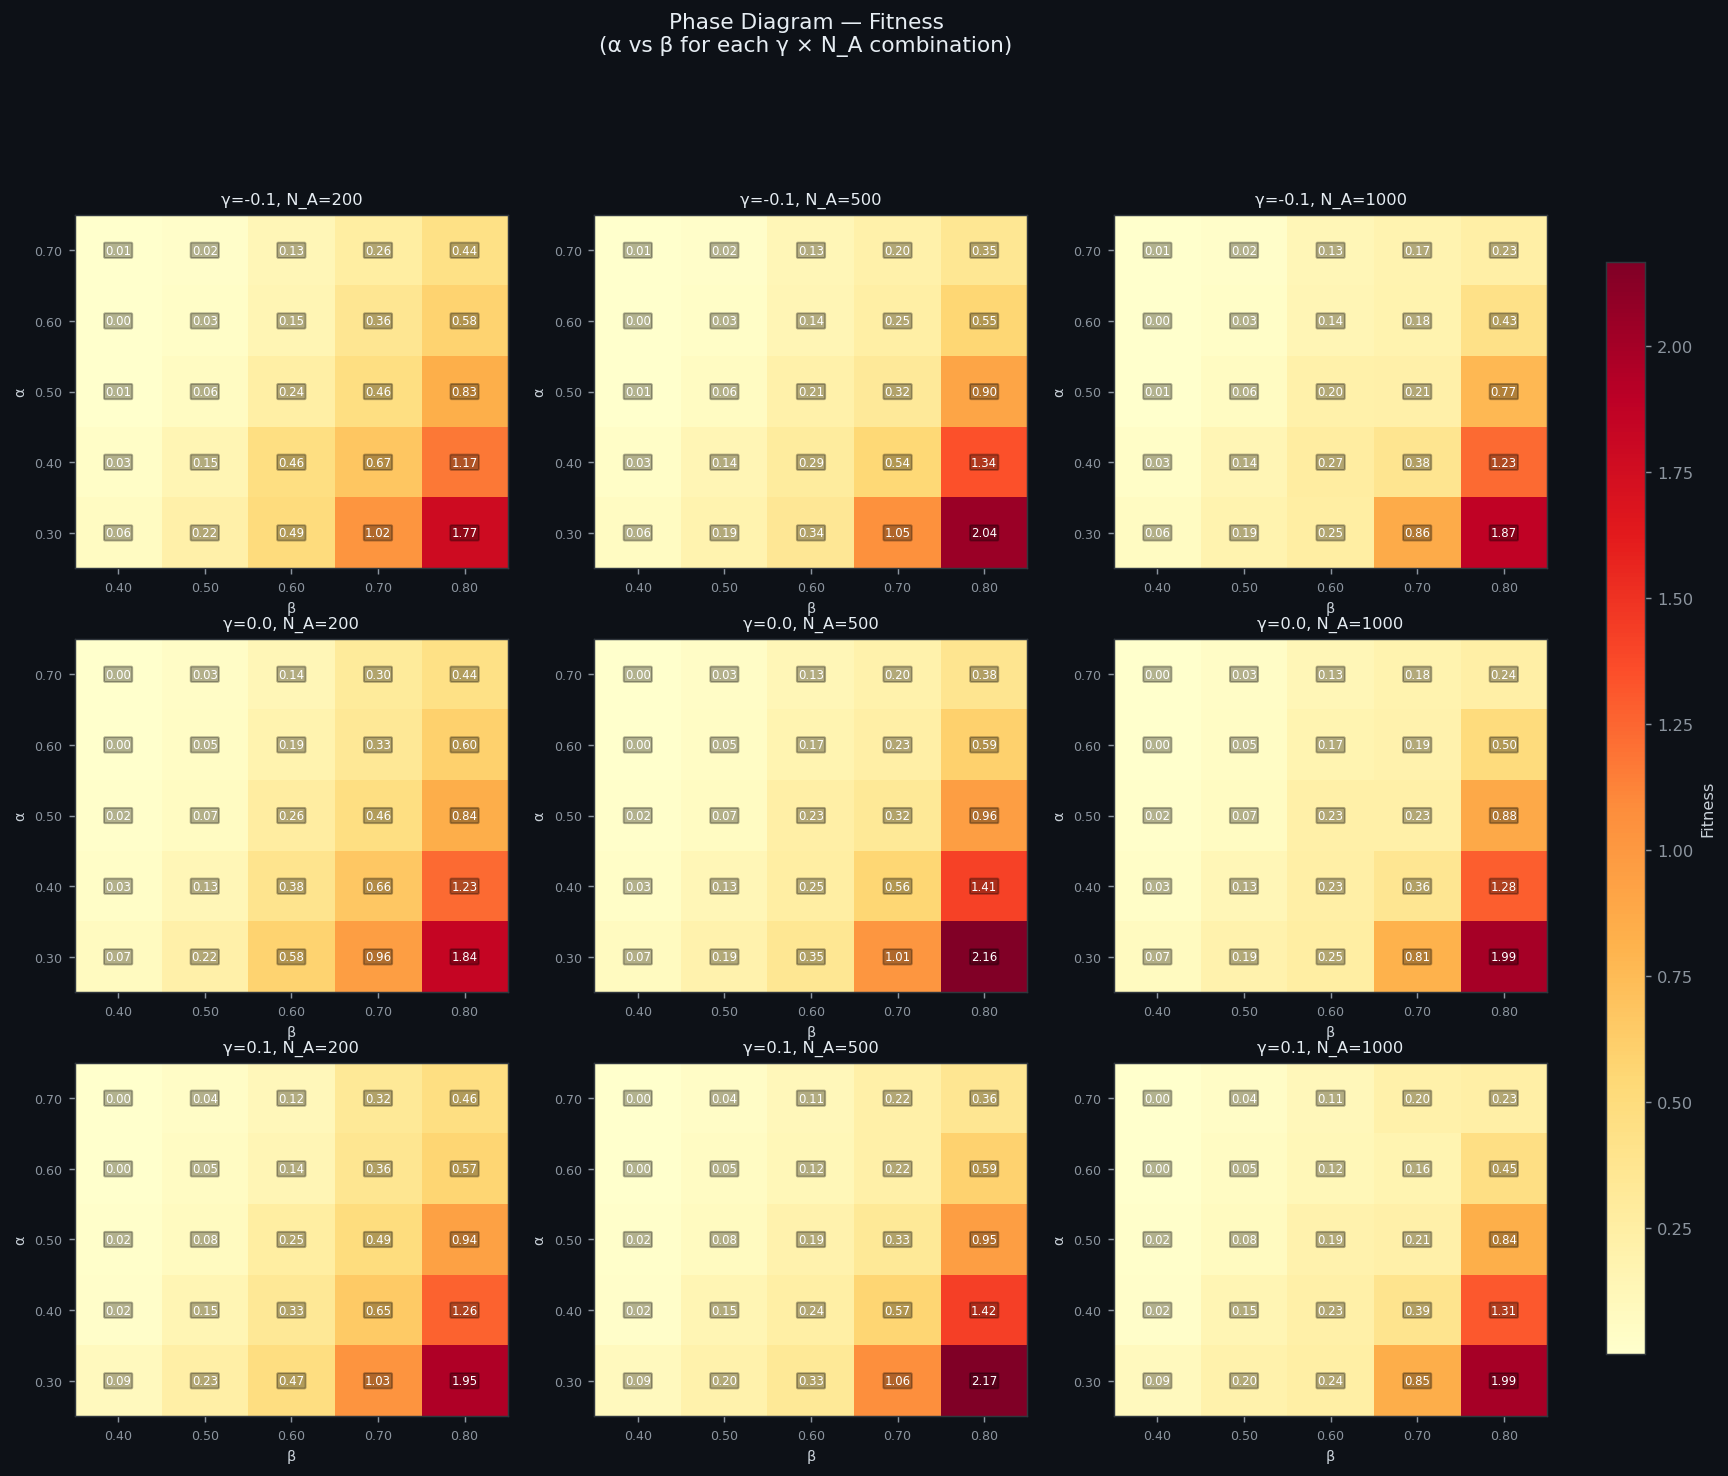

  Saved results\225 pairs-100 runs\pareto_plots\04_phase_heatmaps_fitness.png


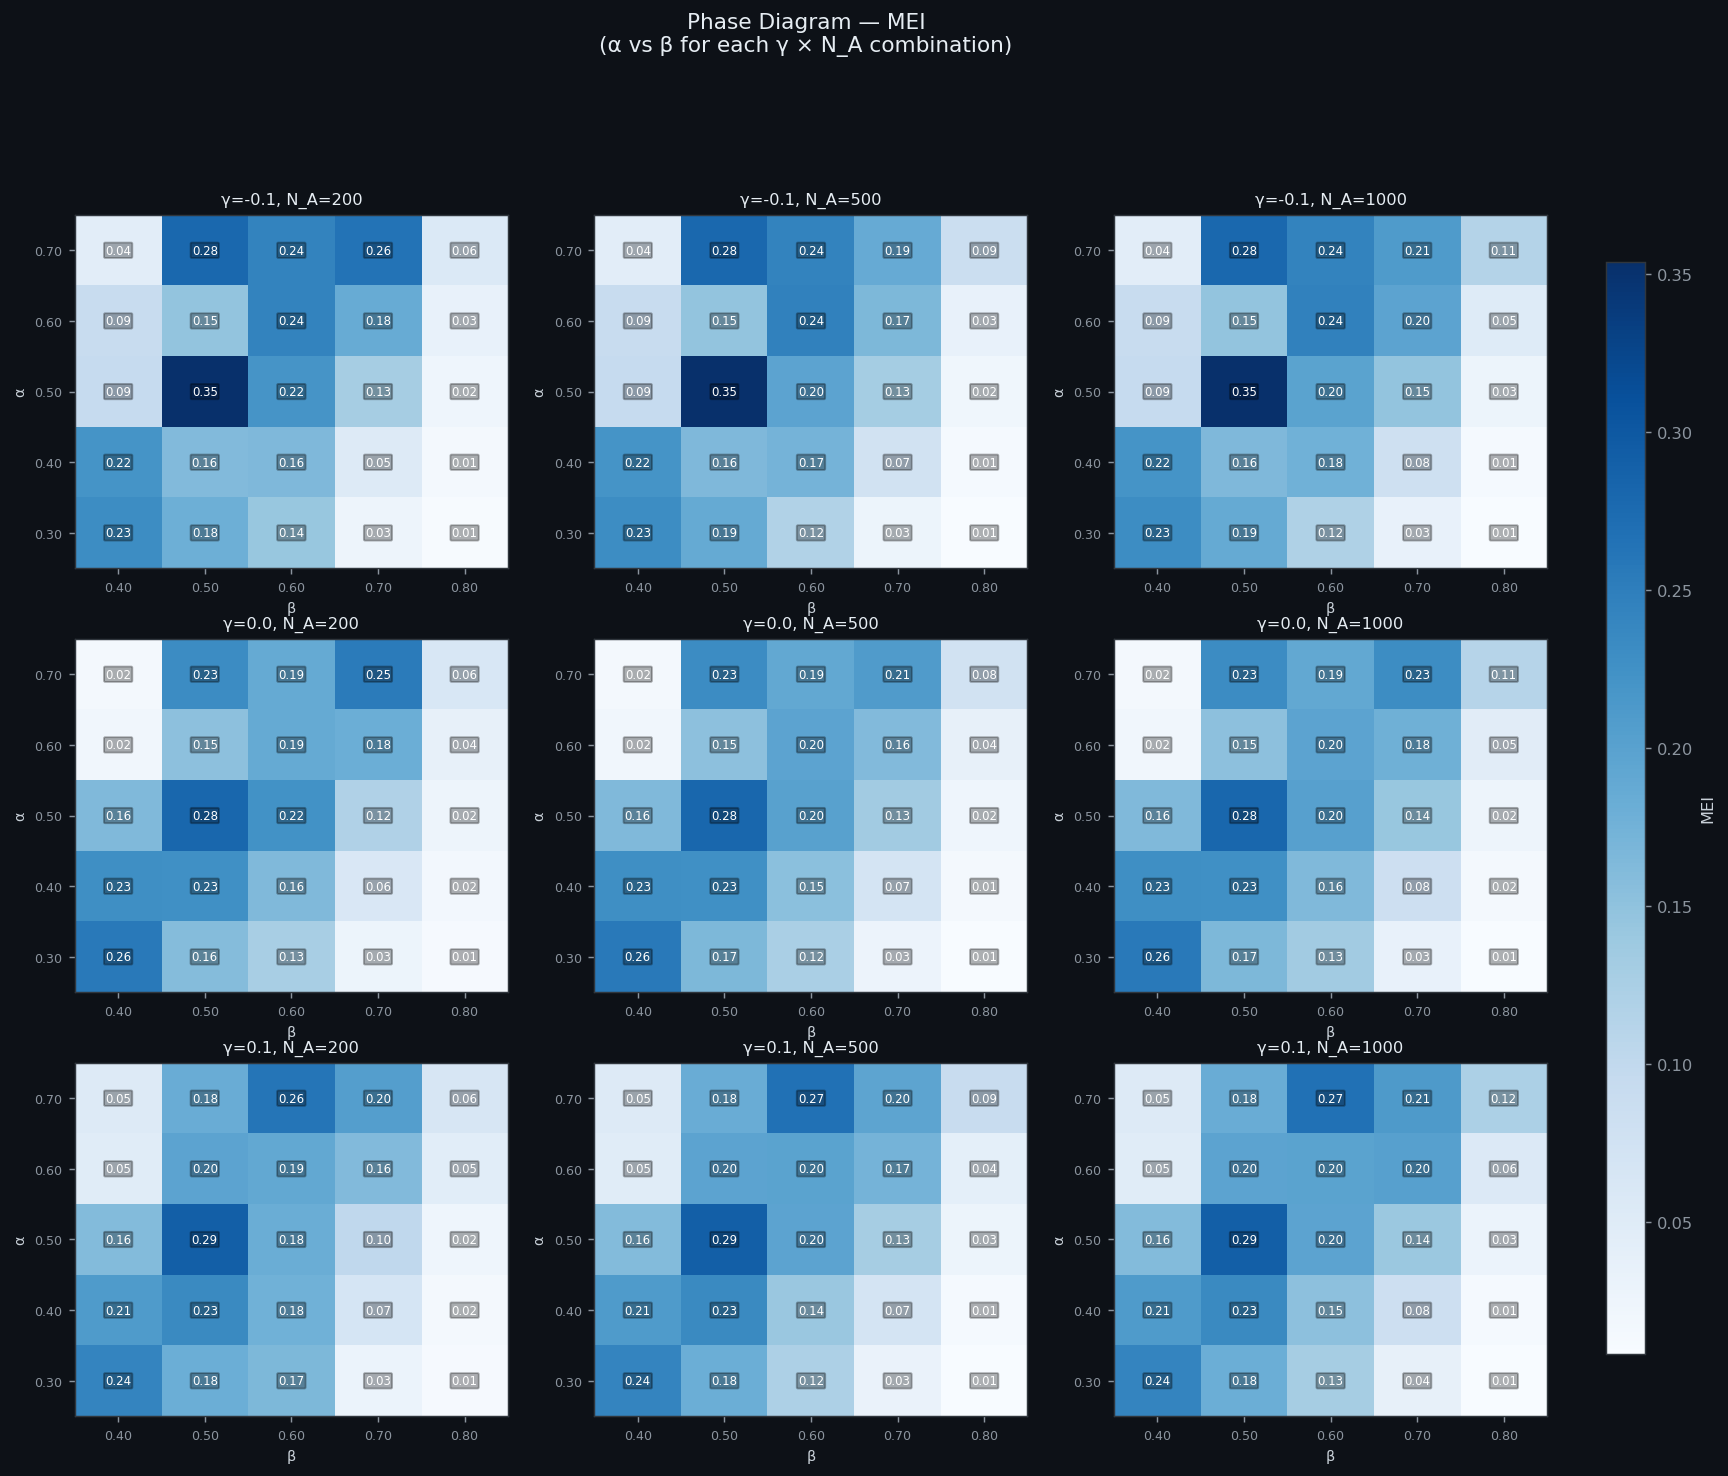

  Saved results\225 pairs-100 runs\pareto_plots\04_phase_heatmaps_mei.png


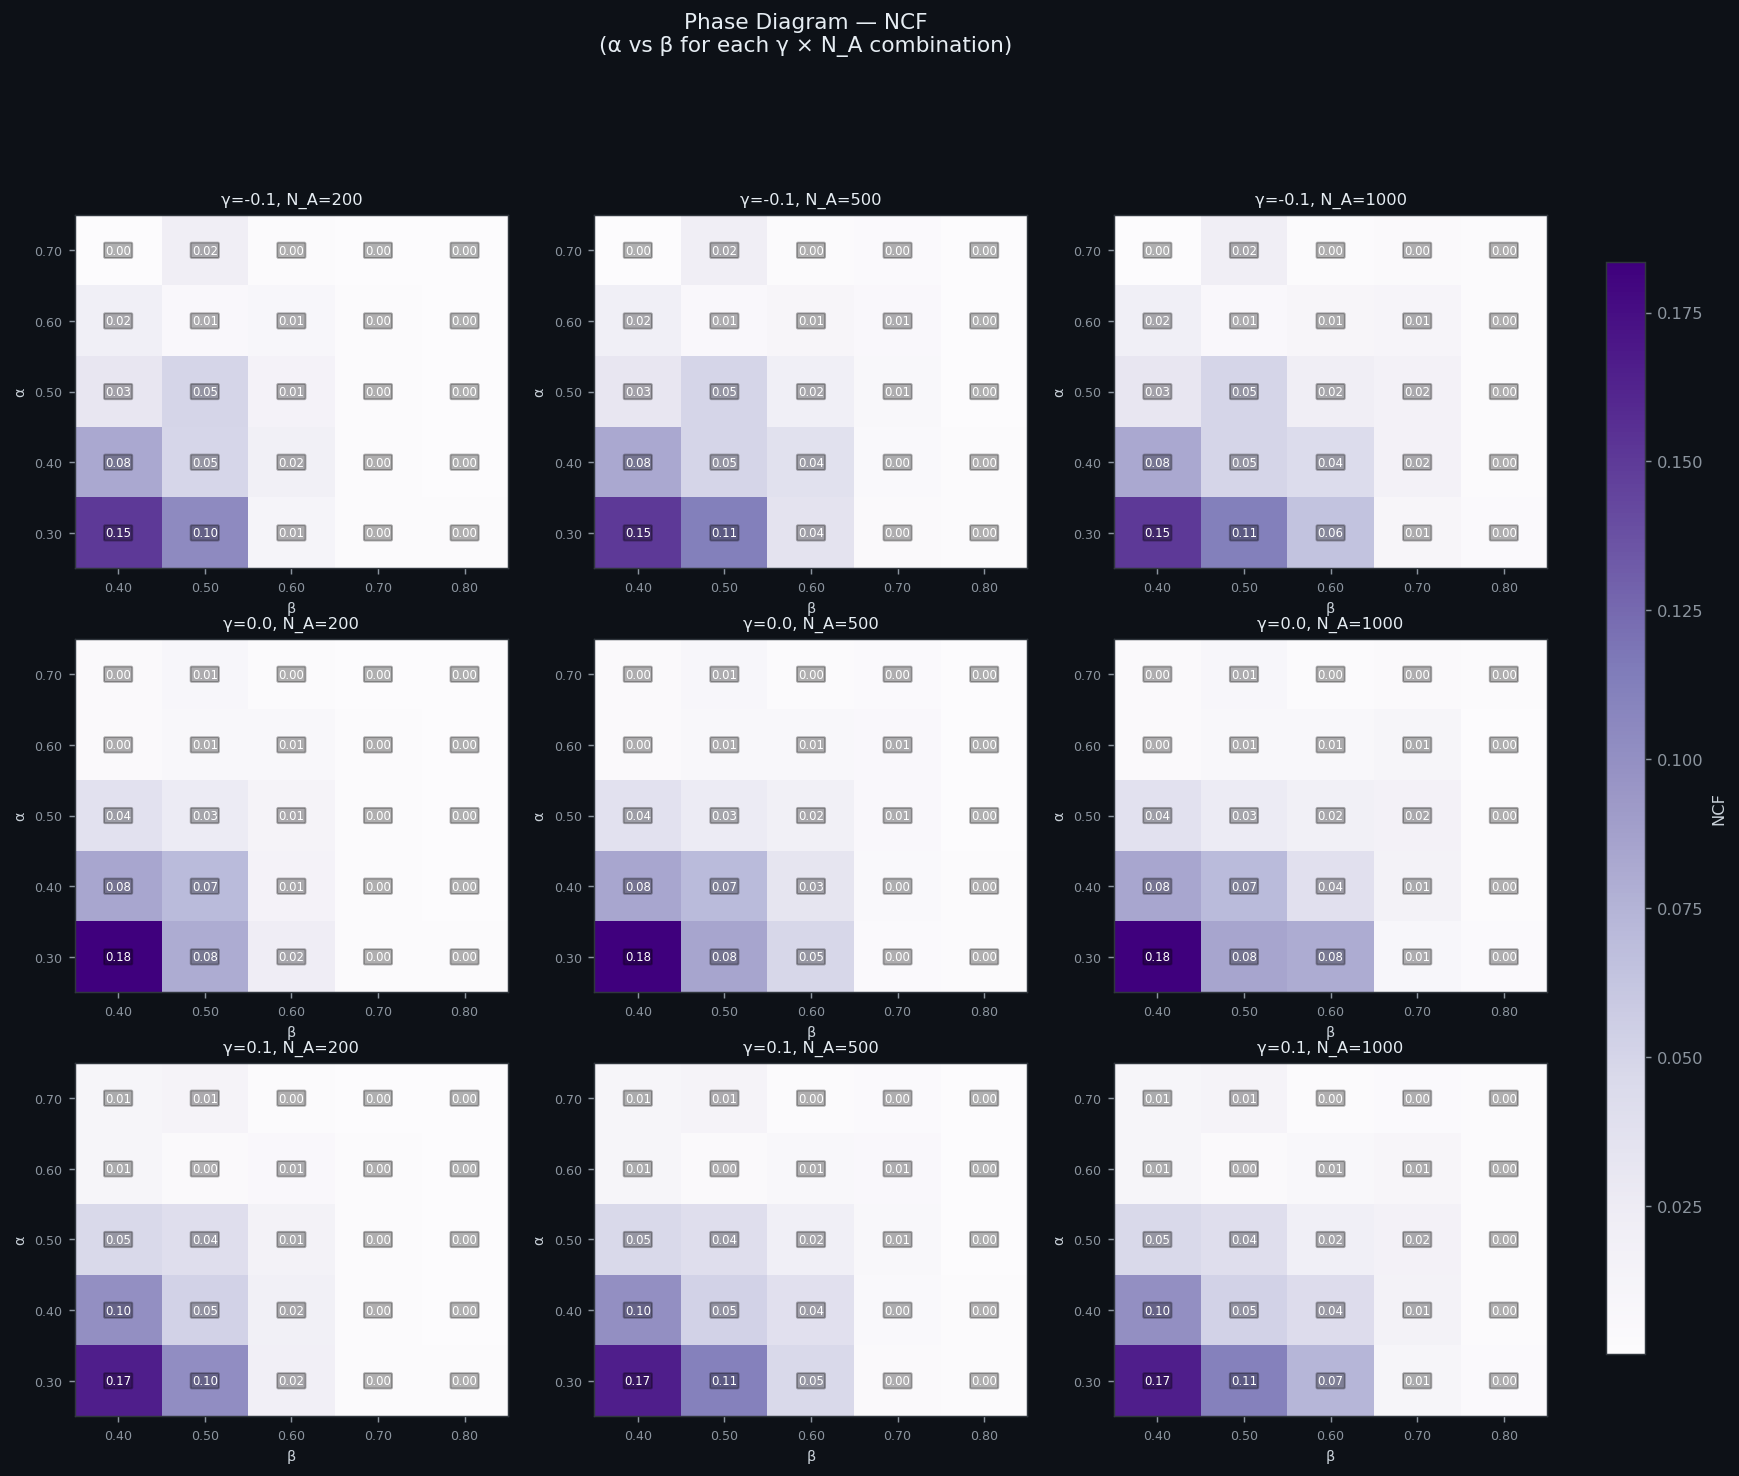

  Saved results\225 pairs-100 runs\pareto_plots\04_phase_heatmaps_ncf.png


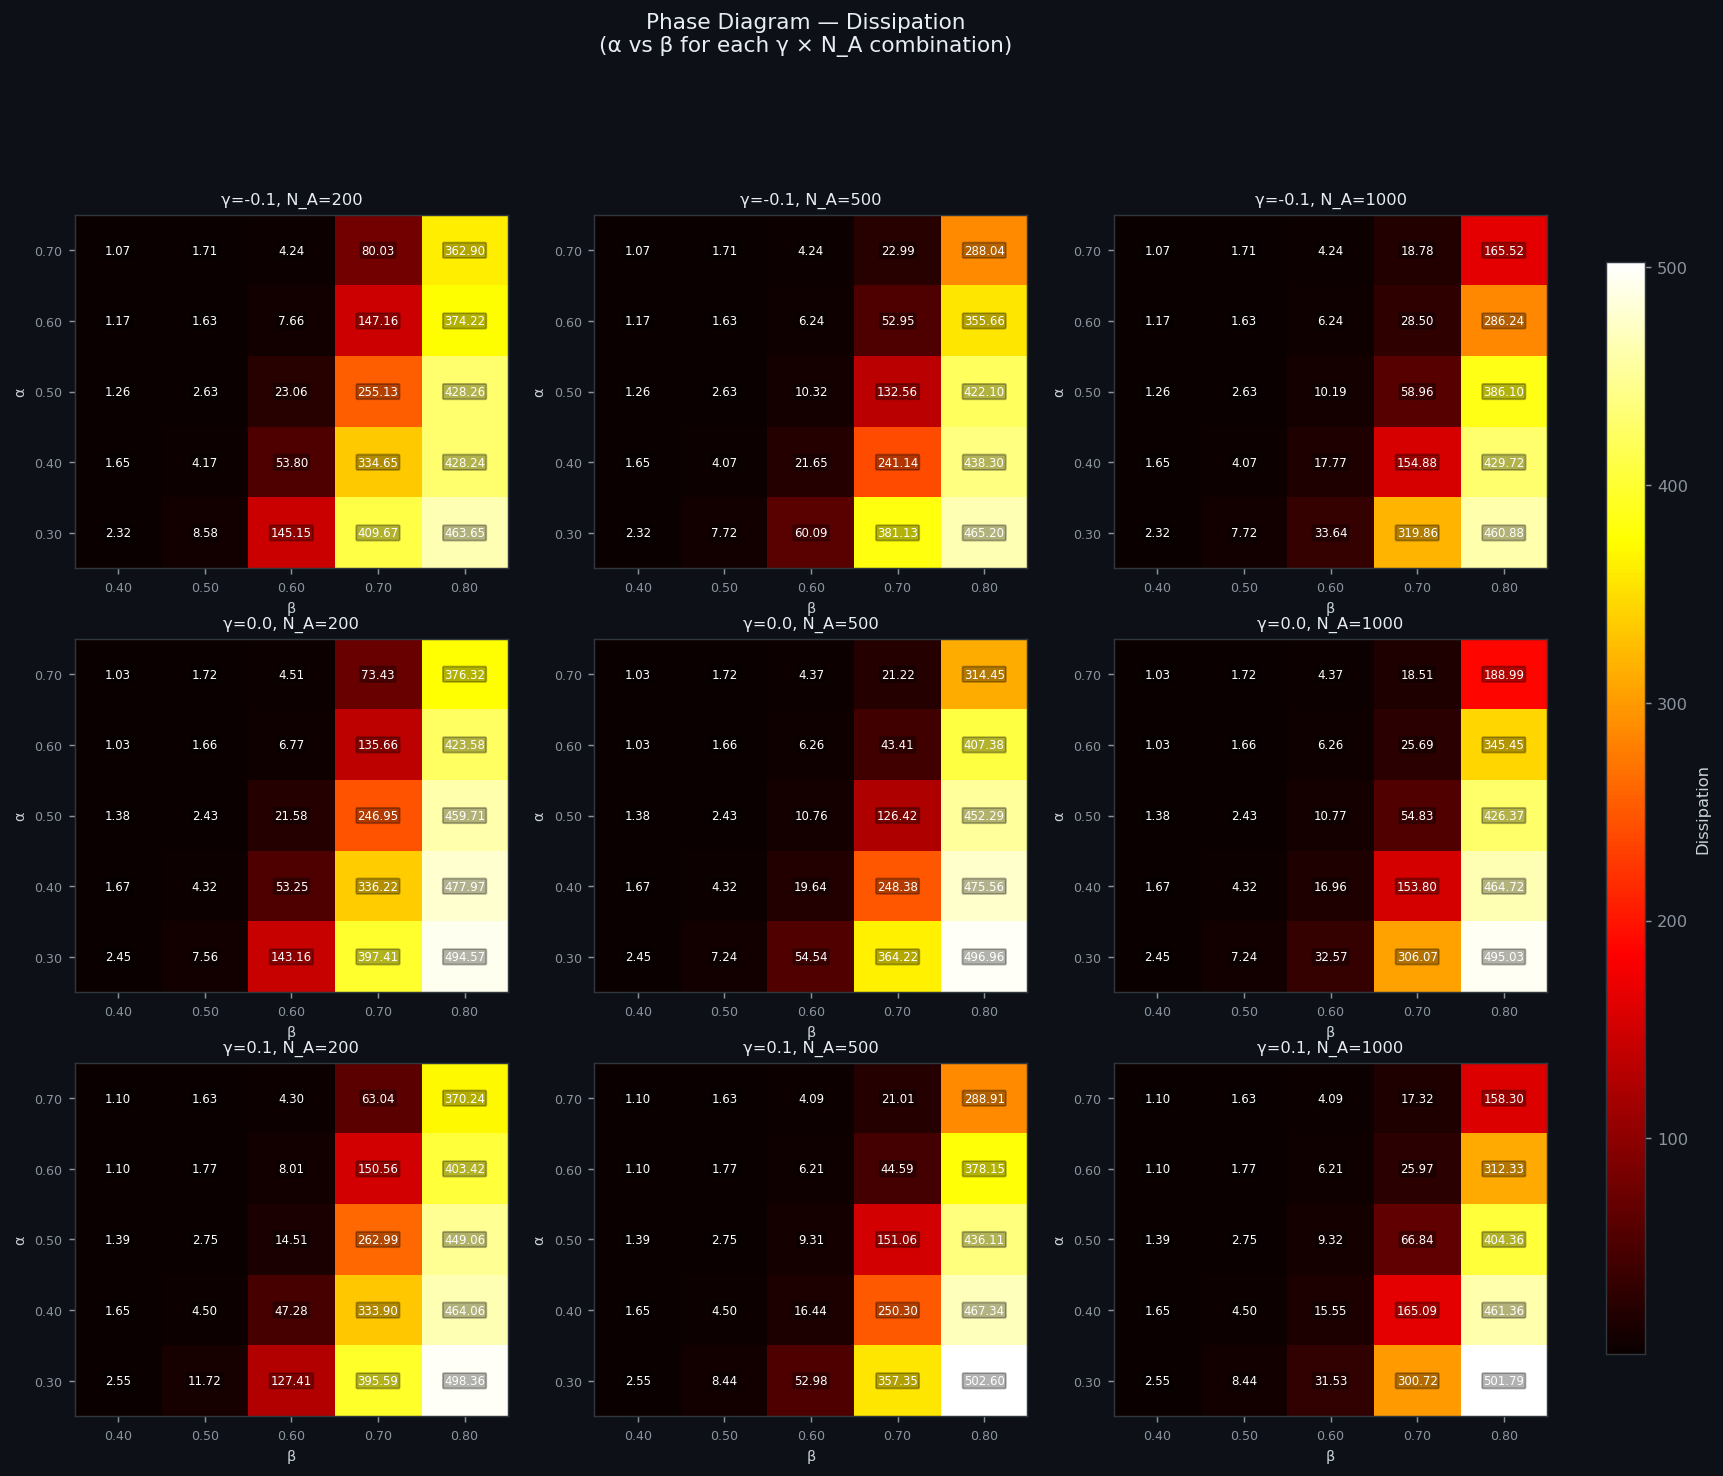

  Saved results\225 pairs-100 runs\pareto_plots\04_phase_heatmaps_dissipation.png


In [117]:
fig04_phase_heatmaps(pf)

  Loading raw_runs.csv for time evolution …


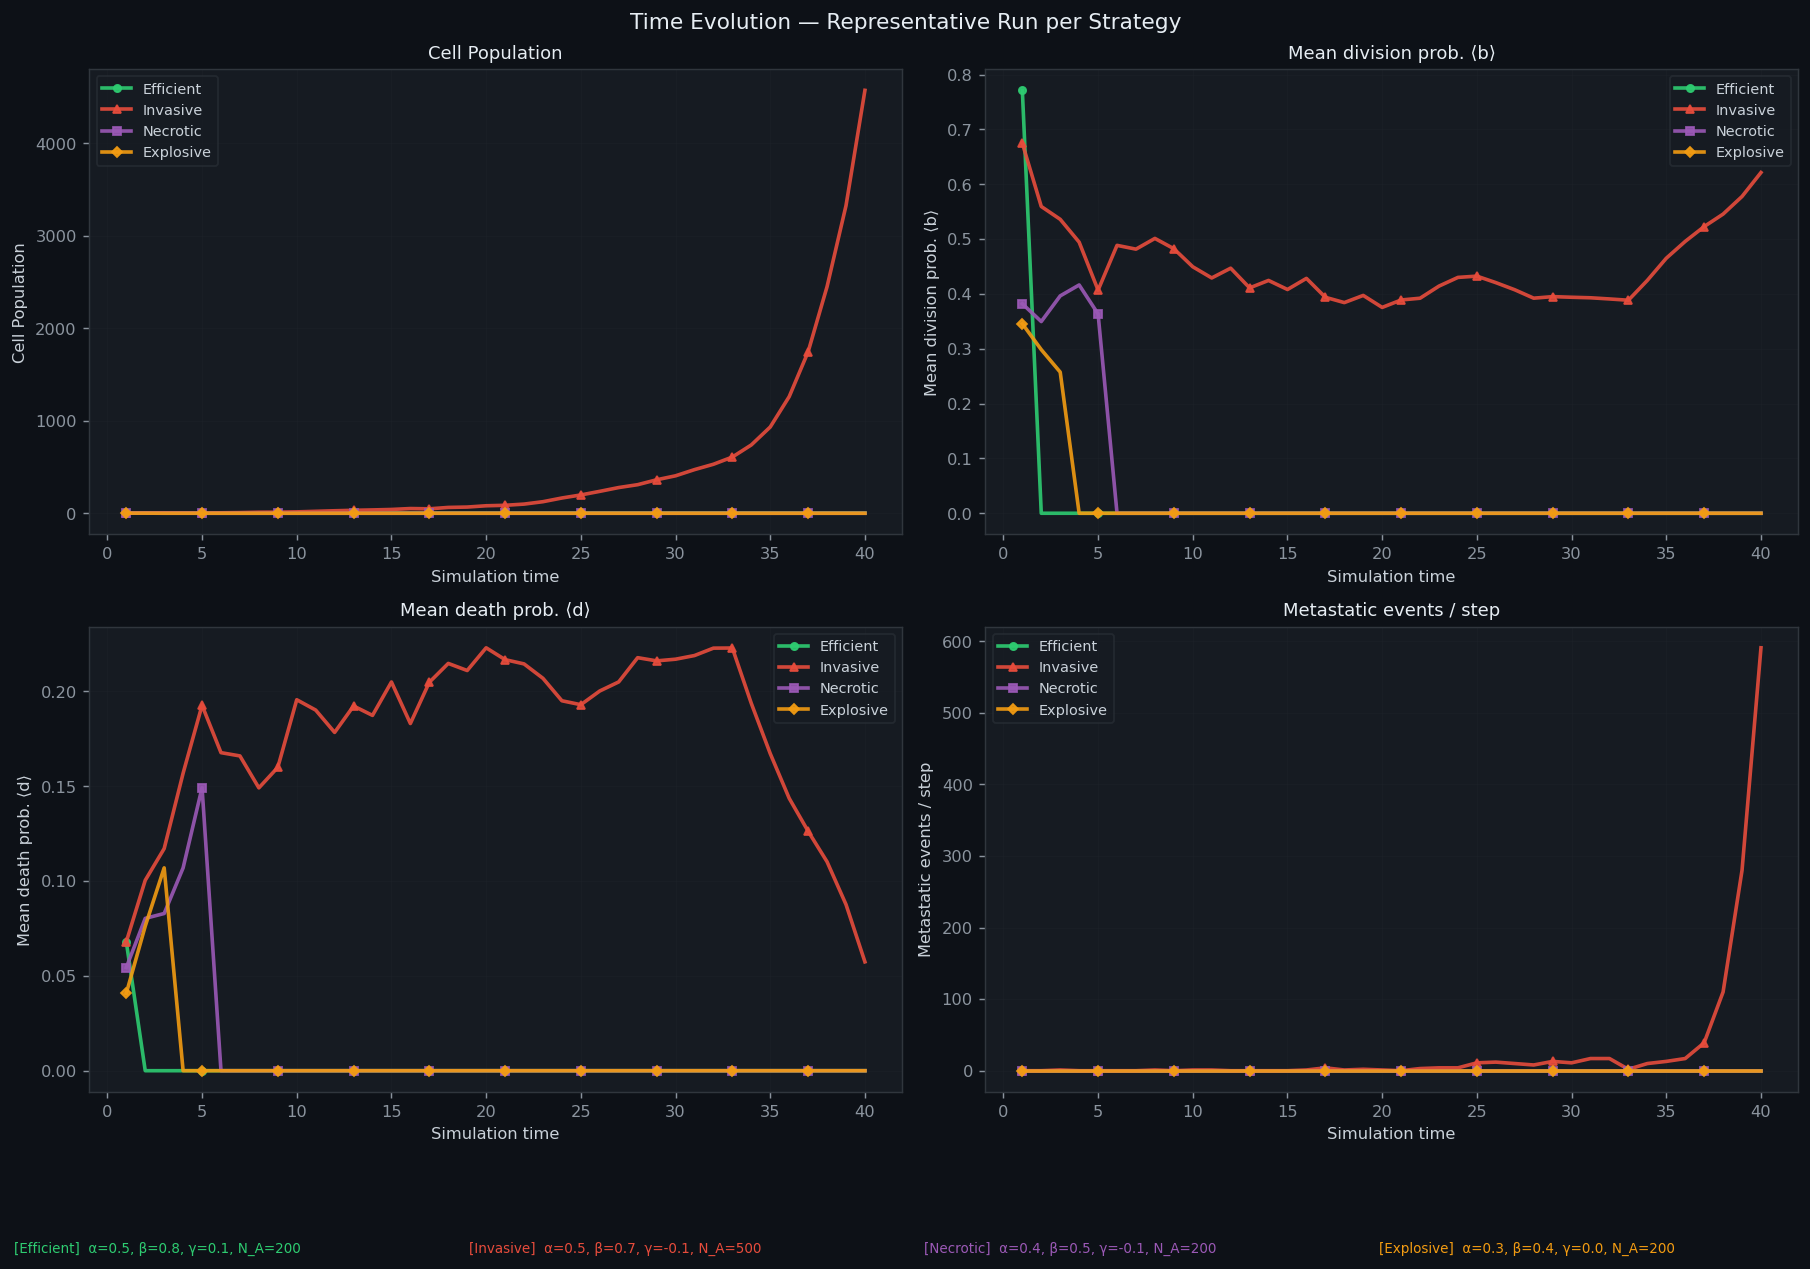

  Saved results\225 pairs-100 runs\pareto_plots\05_time_evolution.png


In [118]:
fig05_time_evolution(front, run)

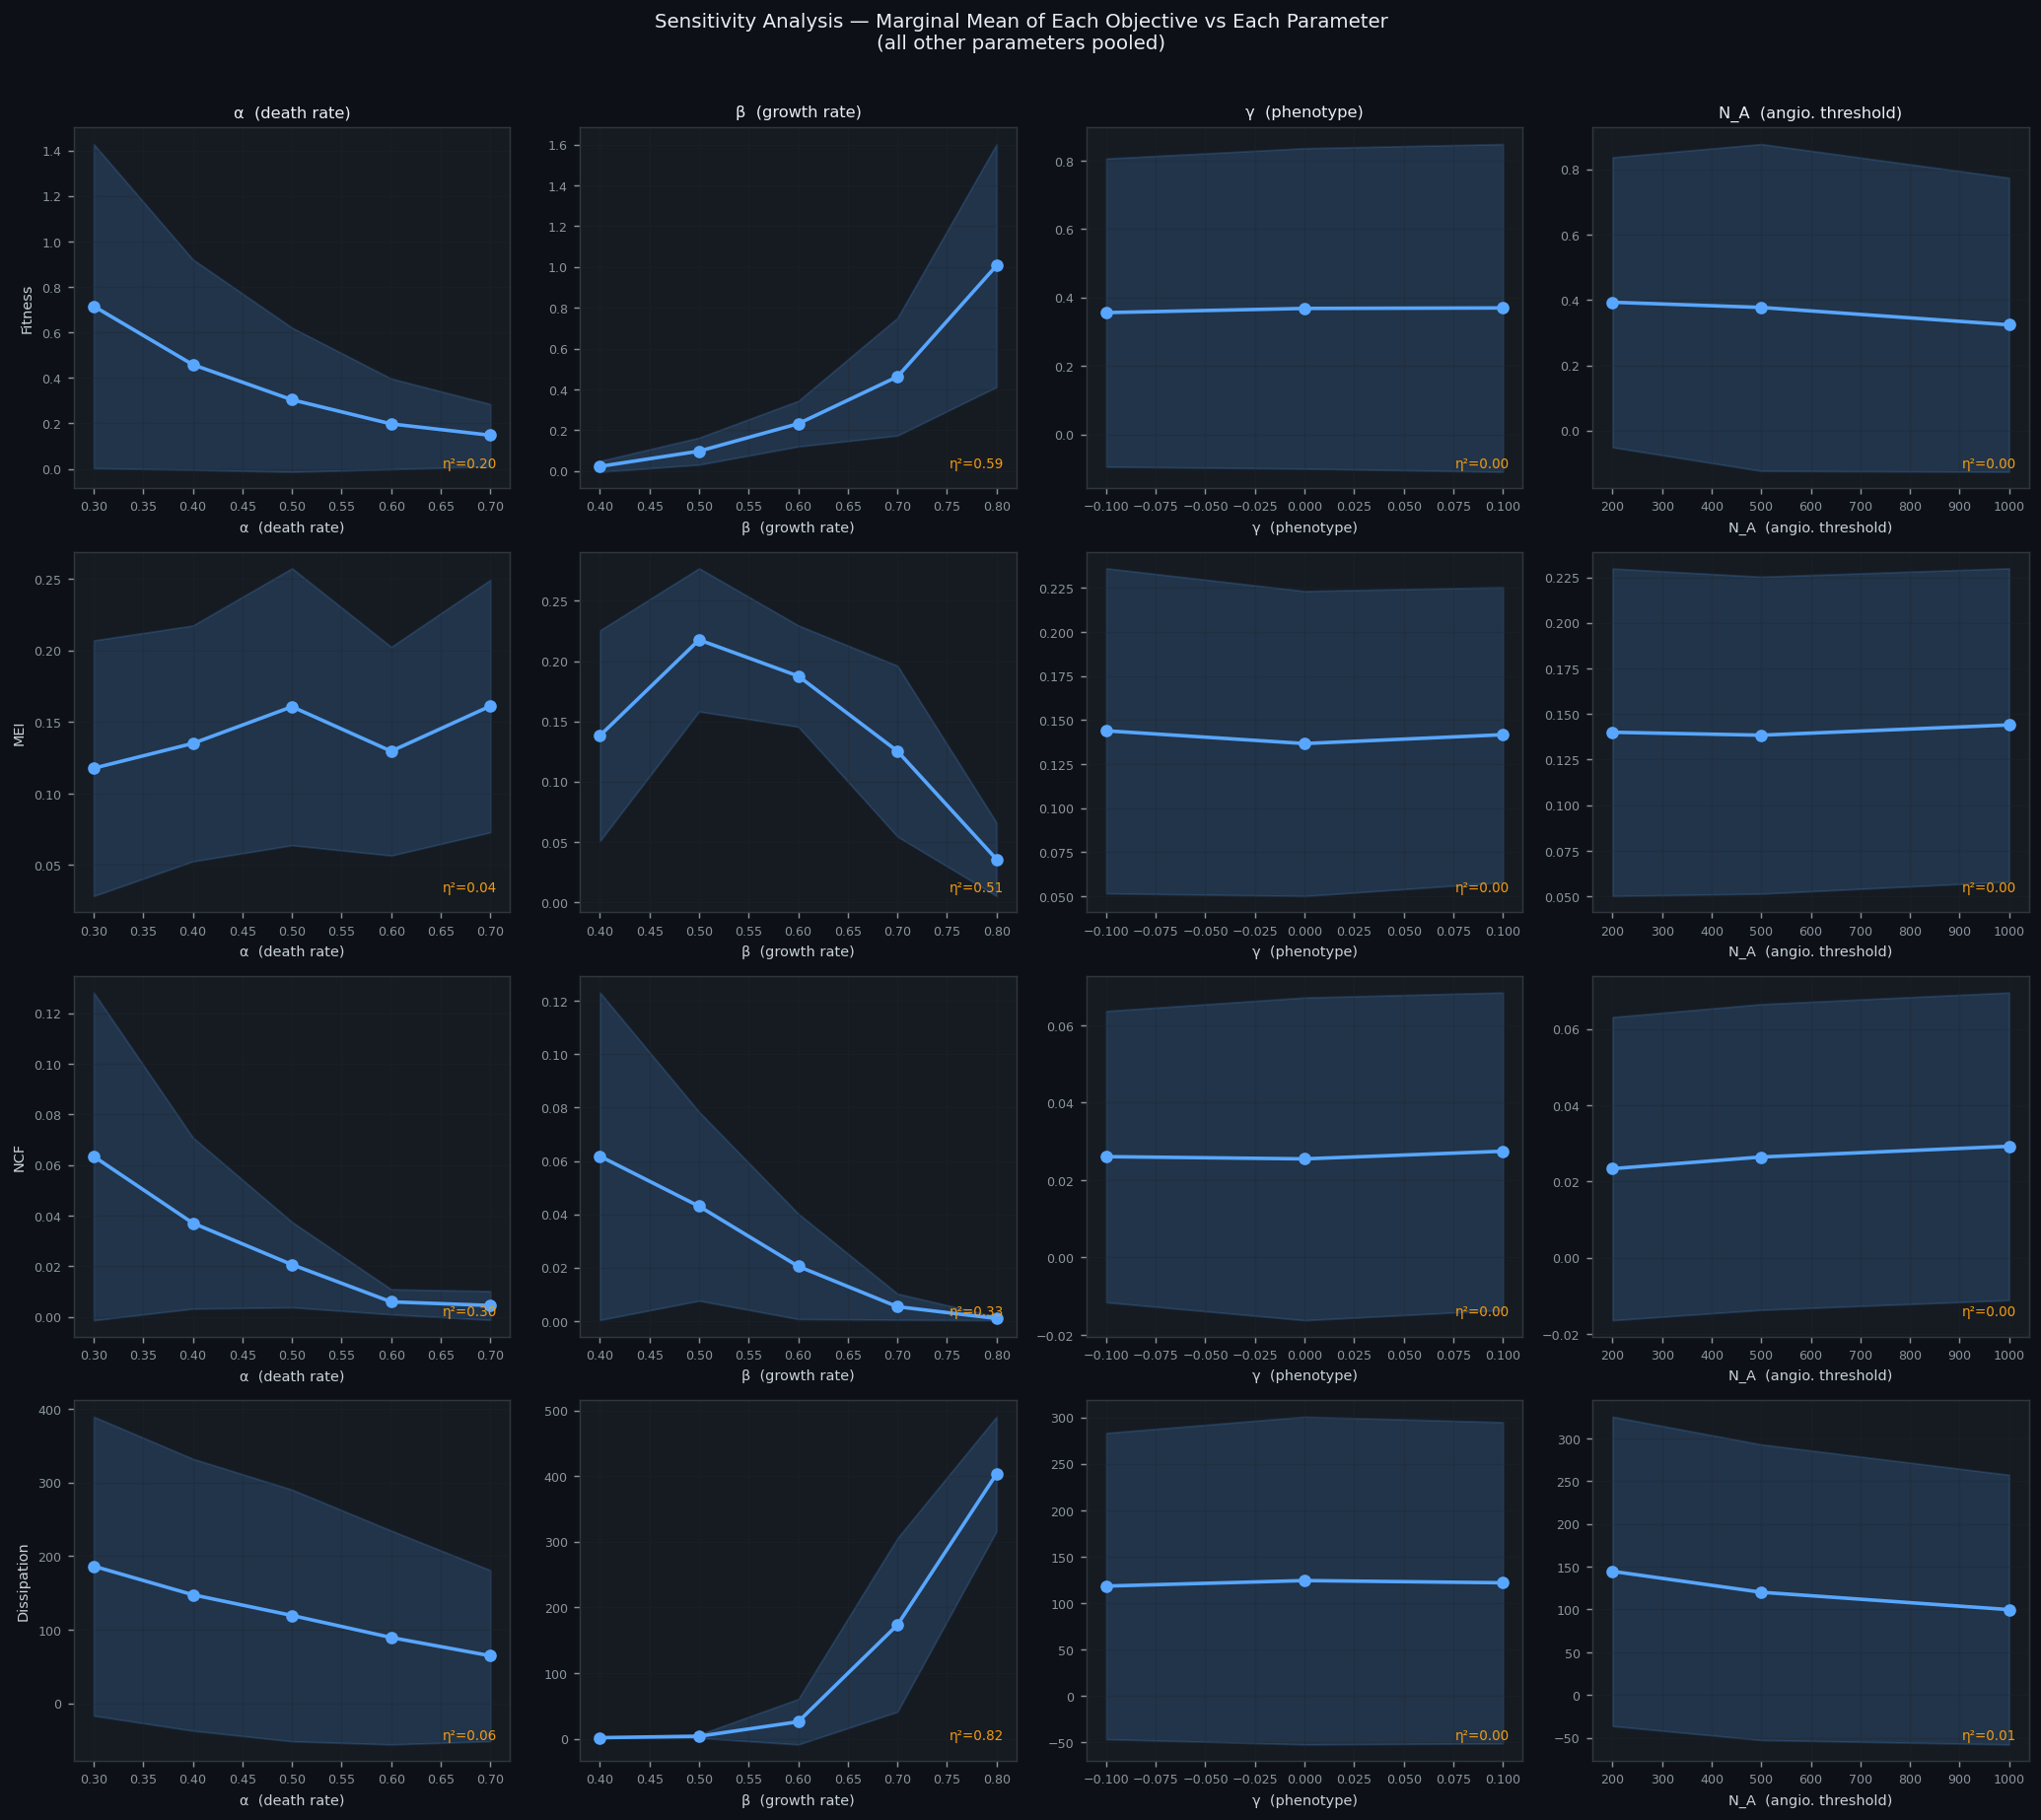

  Saved results\225 pairs-100 runs\pareto_plots\06_sensitivity.png


In [119]:
fig06_sensitivity(pf)

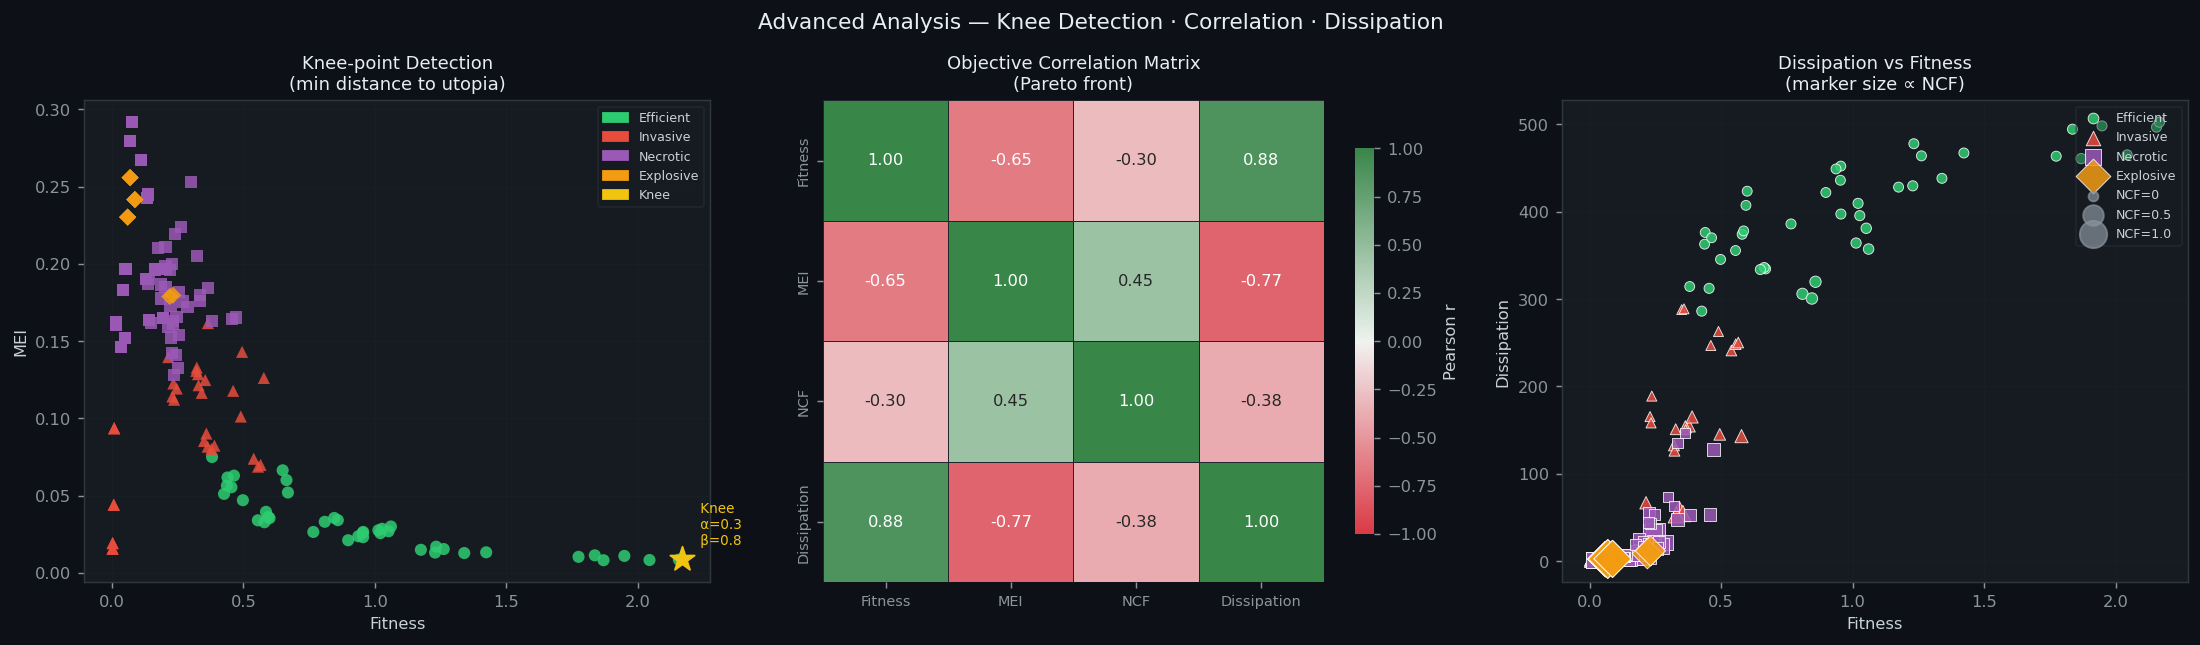

  Saved results\225 pairs-100 runs\pareto_plots\07_advanced.png


In [120]:
fig07_advanced(front)

In [121]:
print(f"\nDone. All figures saved to ./{PLOT_DIR}/")


Done. All figures saved to ./results/225 pairs-100 runs/pareto_plots/
